# Conversation Evaluation EDA

**Structure:**
- **Part 1 (Definitions):** Imports, constants, experiment registry, data loading, stats, plots — run all once.
- **Part 2 (Load & Prepare):** Load data + evaluations in 2 cells.
- **Part 3 (Model Selection):** Choose which models to compare — pick **one** of 3a / 3b / 3c / 3d.
- **Part 4 (Individual Analyses):** Each analysis is its own cell — run any subset.

> **Tip:** After running Parts 1–2 once, re-run any Part 3 cell to switch selection, then re-run any Part 4 cell.

---
# Part 1: Definitions

Run all cells in this section once. They define functions and constants but produce no output.

## 1.1 Imports & Constants

In [1]:
import os
import sys
import re
import json
import asyncio
from dataclasses import dataclass, field
from typing import Dict, List, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    f_oneway, shapiro, levene, kruskal, mannwhitneyu,
 )
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# Resolve shared modules from workspace root
# Walk up from CWD to find the self-contained experiment root, identified by its key files.
_HELPER_FILES = ['openai_key.txt', 'HF_key.txt']
_cur = os.path.abspath(os.getcwd())
_EXPERIMENT_ROOT = None
for _ in range(8):
    if all(os.path.exists(os.path.join(_cur, _hf)) for _hf in _HELPER_FILES):
        _EXPERIMENT_ROOT = _cur
        break
    _parent = os.path.dirname(_cur)
    if _parent == _cur:
        break
    _cur = _parent
if _EXPERIMENT_ROOT is None or os.path.basename(_EXPERIMENT_ROOT) != 'Exp2_PTO':
    raise RuntimeError(f'Could not locate Exp2_PTO experiment root from {os.getcwd()!r}')
if _EXPERIMENT_ROOT not in sys.path:
    sys.path.insert(0, _EXPERIMENT_ROOT)

# Map legacy `LLM_DATA/...` path prefixes to the new experiment-rooted layout.
_PATH_REMAP = [
    ("LLM_DATA/Conversation_with_Eval_V3/", "data/conversations_eval"),
    ("LLM_DATA/Conversation_Trees_V3/",     "data/conversation_trees"),
    ("LLM_DATA/Conversation_with_Eval/",    "data/conversations_eval"),
    ("LLM_DATA/Conversation_Trees/",        "data/conversation_trees"),
]

def _resolve_data_path(p):
    for _old, _new in _PATH_REMAP:
        if p.startswith(_old):
            return os.path.join(_EXPERIMENT_ROOT, _new, p[len(_old):])
    return p

# Per-experiment helper modules live under <EXPERIMENT_ROOT>/code (each
# experiment has its own copy with the matching prompt/questionnaire version).
_EXPERIMENT_CODE = os.path.join(_EXPERIMENT_ROOT, "code")
if os.path.isdir(_EXPERIMENT_CODE) and _EXPERIMENT_CODE not in sys.path:
    sys.path.insert(0, _EXPERIMENT_CODE)

from system_prompts_builder import get_patient_permutation_characteristics
print("System prompts module imported from:")
path = sys.modules['system_prompts_builder'].__file__
print(f"  {path}")

# ── Figure sizes ──
FIG_WIDE = (16, 5)
FIG_SINGLE = (12, 5)

# ── Statistical constants ──
ALPHA = 0.05
EFFECT_SIZE_THRESHOLDS = {"small": 0.2, "medium": 0.5, "large": 0.8}

# ── Ordering ──
# Edit this list to change the left-to-right order of oracle groups in all plots/tables.
ORACLE_ORDER = ["WAI", "CSQ8", "Q1Q2", "MI_SAT", "MITI"]

# Sort order for experiment groups. Lower = appears first.
# DPO models (L0_*/L5_*) all share rank 1 (between Base=0 and GRPO=2).
GROUP_ORDER = {"Base": 0, "GRPO": 2, "GRPO-Instruct": 3, "GRPO_V2": 4}
DPO_GROUP_ORDER = 1  # All DPO (L0/L5) variants share this rank

EXPERIMENT_PALETTE = {
    "Base": "orange",
    "L0_Q1Q2": "#1f77b4", "L5_Q1Q2": "#6baed6",
    "L0_CSQ8": "#2ca02c", "L5_CSQ8": "#74c476",
    "L0_WAI": "#d62728", "L5_WAI": "#fb6a4a",
    "L0_MITI": "#9467bd", "L5_MITI": "#bcbddc",
    "GRPO": "#e377c2", "GRPO-Instruct": "#f7b6d2", "GRPO_V2": "#aec7e8",
}

# oracle key -> (display name for plots, DataFrame column name)
ORACLE_METRIC_MAP = {
    "WAI":    ("WAI-SR",  "WAI_TotalMean"),
    "CSQ8":   ("CSQ-8",   "CSQ8_Mean"),
    "Q1Q2":   ("Q1+Q2",   "Q1Q2_Mean"),
    "MI_SAT": ("MI-SAT",  "MI_Mean"),
    "MITI":   ("MITI",    "MITI_GlobalMean"),
    "Q1":     ("Q1",      "Q1_Mean"),
    "Q2":     ("Q2",      "Q2_Mean"),
}

# ── Eval model settings ──
EVAL_MODEL = "gpt-4o-mini-2024-07-18"
EVAL_TEMPERATURE = 0.1
MAX_RETRIES = 3
DEFAULT_CONCURRENCY = 32

# ── Plot style ──
def set_plot_style():
    plt.style.use("seaborn-v0_8-whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    plt.rcParams["figure.dpi"] = 100
    plt.rcParams["savefig.dpi"] = 150

# ── Dataclasses ──
@dataclass
class EDAConfig:
    run_evaluation: bool = False # Set to True to run evaluations (requires API access and eval data)
    eval_base_dir: str = os.path.join(_EXPERIMENT_ROOT, "eda", "eval")
    eval_model: str = EVAL_MODEL
    eval_temp: float = EVAL_TEMPERATURE
    async_concurrency: int = DEFAULT_CONCURRENCY
    eval_folders: Dict[str, str] = field(default_factory=dict)

    def __post_init__(self):
        if not self.eval_folders:
            self.eval_folders = {
                "CSQ-8": f"{self.eval_base_dir}/CSQ8/",
                "WAI-SR": f"{self.eval_base_dir}/WAI_SR/",
                "MI-SAT": f"{self.eval_base_dir}/MI_SAT/",
                "MITI": f"{self.eval_base_dir}/MITI/",
                "Q1": f"{self.eval_base_dir}/Q1/",
                "Q2": f"{self.eval_base_dir}/Q2/",
            }

@dataclass
class PlotContext:
    model_palette: dict = field(default_factory=dict)
    experiment_palette: dict = field(default_factory=dict)
    hue_col: str = "ExperimentGroup"
    model_order: Optional[list] = None
    baseline_model: str = "Base"
    show: bool = True

print("1.1 loaded: imports, constants, config.")


System prompts module imported from:
  c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp2_PTO\code\system_prompts_builder.py
1.1 loaded: imports, constants, config.


## 1.2 Experiment Registry

In [2]:
@dataclass
class Experiment:
    """Describes a single experiment configuration."""
    oracle: str
    lookahead: Optional[int]
    version: Optional[int]
    path: str
    method: str = "DPO"
    epoch: Optional[int] = None

    @property
    def model_name(self) -> str:
        if self.oracle == "Base":
            if self.method == "GRPO-Instruct":
                return "GRPOI_Base"
            if self.method == "GRPO_V2":
                return "GRPOV2_Base"  # epoch=0 = base model
            return "Base"
        if self.method == "GRPO":
            return f"GRPO_E{self.epoch}"
        if self.method == "GRPO-Instruct":
            return f"GRPOI_E{self.epoch}"
        if self.method == "GRPO_V2":
            return "GRPOV2_Base" if self.epoch == 0 else f"GRPOV2_I{self.epoch}"
        return f"L{self.lookahead}_{self.oracle}_V{self.version}"


EXPERIMENTS: List[Experiment] = [
    # Base
    Experiment("Base", None, None, "LLM_DATA/Conversation_with_Eval_V3/Base/Good_50_TT0.9_TP0.7_TE0.1"),

    # L0 WAI
    Experiment("WAI", 0, 1, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V1"),
    Experiment("WAI", 0, 2, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V2"),
    Experiment("WAI", 0, 3, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V3"),
    Experiment("WAI", 0, 4, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V4"),
    Experiment("WAI", 0, 5, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V5"),

    # L0 CSQ8
    Experiment("CSQ8", 0, 1, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V1"),
    Experiment("CSQ8", 0, 2, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V2"),
    Experiment("CSQ8", 0, 3, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V3"),
    Experiment("CSQ8", 0, 4, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V4"),
    Experiment("CSQ8", 0, 5, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.1_V5"),

    # L0 Q1Q2
    Experiment("Q1Q2", 0, 1, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.2_V1"),
    Experiment("Q1Q2", 0, 2, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.2_V2"),
    Experiment("Q1Q2", 0, 3, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.2_V3"),
    Experiment("Q1Q2", 0, 4, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.2_V4"),
    Experiment("Q1Q2", 0, 5, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_0/TTree1.2_TT0.9_TP0.7_TE0.2_V5"),

    # L5 WAI
    Experiment("WAI", 5, 1, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V1"),
    Experiment("WAI", 5, 2, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V2"),
    Experiment("WAI", 5, 3, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V3"),
    Experiment("WAI", 5, 4, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V4"),
    Experiment("WAI", 5, 5, "LLM_DATA/Conversation_with_Eval_V3/WAI/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V5"),

    # L5 CSQ8
    Experiment("CSQ8", 5, 1, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V1"),
    Experiment("CSQ8", 5, 2, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V2"),
    Experiment("CSQ8", 5, 3, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V3"),
    Experiment("CSQ8", 5, 4, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V4"),
    Experiment("CSQ8", 5, 5, "LLM_DATA/Conversation_with_Eval_V3/CSQ-8/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.1_V5"),

    # L5 Q1Q2
    Experiment("Q1Q2", 5, 1, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V1"),
    Experiment("Q1Q2", 5, 2, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V2"),
    Experiment("Q1Q2", 5, 3, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V3"),
    Experiment("Q1Q2", 5, 4, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V4"),
    Experiment("Q1Q2", 5, 5, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V5"),
    Experiment("Q1Q2", 5, 6, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V6"),
    Experiment("Q1Q2", 5, 7, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V7"),
    Experiment("Q1Q2", 5, 8, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V8"),
    Experiment("Q1Q2", 5, 9, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V9"),
    Experiment("Q1Q2", 5, 10, "LLM_DATA/Conversation_with_Eval_V3/Q1Q2/LookAhead_5/TTree1.2_TT0.9_TP0.7_TE0.2_V10"),

    # GRPO
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch3_TT0.9_TP0.7", method="GRPO", epoch=3),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch6_TT0.9_TP0.7", method="GRPO", epoch=6),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch9_TT0.9_TP0.7", method="GRPO", epoch=9),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch12_TT0.9_TP0.7", method="GRPO", epoch=12),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch15_TT0.9_TP0.7", method="GRPO", epoch=15),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch18_TT0.9_TP0.7", method="GRPO", epoch=18),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch21_TT0.9_TP0.7", method="GRPO", epoch=21),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO/GRPO_Epoch24_TT0.9_TP0.7", method="GRPO", epoch=24),

    # GRPO-Instruct
    Experiment("Base",  None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Base_TT0.9_TP0.7",    method="GRPO-Instruct", epoch=0),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Epoch3_TT0.9_TP0.7",  method="GRPO-Instruct", epoch=3),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Epoch6_TT0.9_TP0.7",  method="GRPO-Instruct", epoch=6),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Epoch9_TT0.9_TP0.7",  method="GRPO-Instruct", epoch=9),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Epoch12_TT0.9_TP0.7", method="GRPO-Instruct", epoch=12),
    Experiment("Q1Q2", None, None, "LLM_DATA/Conversation_with_Eval_V3/GRPO-Instruct/GRPO_Epoch15_TT0.9_TP0.7", method="GRPO-Instruct", epoch=15),

    # GRPO_V2 — update _GRPOV2_EXP to match EXPERIMENT_NAME in train_GRPO_Iterative.ipynb
    # epoch=0 → GRPOV2_Base (base model run), epoch=N → GRPOV2_IN (after N-th training cycle)
    # Uncomment lines below as iterations are completed:
    # _GRPOV2_EXP = "GRPO_Iterative_Oracle_Llama32-1B_LA5_G4"
    # Experiment("Base",  None, None, f"LLM_DATA/Conversations/GRPO/{_GRPOV2_EXP}/GRPO_Iter0_TT0.9_TP0.7", method="GRPO_V2", epoch=0),
    # Experiment("Q1Q2", None, None, f"LLM_DATA/Conversations/GRPO/{_GRPOV2_EXP}/GRPO_Iter1_TT0.9_TP0.7", method="GRPO_V2", epoch=1),
    # Experiment("Q1Q2", None, None, f"LLM_DATA/Conversations/GRPO/{_GRPOV2_EXP}/GRPO_Iter2_TT0.9_TP0.7", method="GRPO_V2", epoch=2),
]


def get_data_paths(experiments=None):
    experiments = experiments or EXPERIMENTS
    return [e.path for e in experiments]

def get_model_names(experiments=None):
    experiments = experiments or EXPERIMENTS
    return [e.model_name for e in experiments]

def resolve_paths(experiments=None):
    paths = get_data_paths(experiments)
    return [_resolve_data_path(p) for p in paths]

print(f"1.2 loaded: {len(EXPERIMENTS)} experiments registered.")

1.2 loaded: 50 experiments registered.


## 1.3 Data Loading & Metadata

In [3]:
# ── Conversation loading ──

def preprocess_conversation(conversation_df: pd.DataFrame, conversation_id: int = -1) -> dict:
    # Normalize column names: handle legacy typo (session_endded_by) and
    # GRPO_V2 format (session_ended_by) transparently.
    df = conversation_df.rename(columns={
        "session_endded_by": "session_ended_by",
        "session_endded_explanation": "session_ended_explanation",
    })
    utterances = df["conversation"].tolist()
    return {
        "id": conversation_id,
        "conversation_length": len(utterances),
        "session_ended_by": df["session_ended_by"].iloc[0],
        "session_ended_explanation": df["session_ended_explanation"].iloc[0],
        "conversation": utterances,
    }

def load_conversations(data_path: str, start_idx: int = 0, end_idx: int = 96) -> pd.DataFrame:
    """Load up to 96 conversations from a directory of conversation_{i}.csv files.

    Args:
        data_path: Directory containing conversation_0.csv ... conversation_95.csv.
        start_idx: First conversation index to load (inclusive).
        end_idx: Last conversation index (exclusive, default 96).
    Returns:
        DataFrame with columns: id, conversation_length, session_ended_by,
        session_ended_explanation, conversation.
    """
    conversations = []
    for conversation_index in range(start_idx, end_idx):
        conversation_file_path = os.path.join(data_path, f"conversation_{conversation_index}.csv")
        try:
            conversation_df = pd.read_csv(conversation_file_path)
            conversations.append(preprocess_conversation(conversation_df, conversation_index))
        except FileNotFoundError:
            pass
    return pd.DataFrame(conversations)

def load_data(data_paths: List[str]) -> List[pd.DataFrame]:
    return [load_conversations(data_path) for data_path in data_paths]

def combine_data(data_sets: List[pd.DataFrame], model_names: List[str]) -> pd.DataFrame:
    """Concatenate per-model DataFrames, adding a 'Model' column to each."""
    return pd.concat(
        [data_set.assign(Model=model_name) for data_set, model_name in zip(data_sets, model_names)],
        ignore_index=True,
    )

def reconstruct_conversation_text(utterances: List[str]) -> str:
    return "\n".join(
        f"[{'THERAPIST' if turn_index % 2 == 0 else 'PATIENT'}]: {utterance}"
        for turn_index, utterance in enumerate(utterances)
    )

def add_patient_characteristics(df: pd.DataFrame, id_col: str = "id") -> pd.DataFrame:
    def _get_patient_characteristics(patient_id):
        try:
            return get_patient_permutation_characteristics(int(patient_id))
        except Exception:
            return {}
    characteristics_df = pd.json_normalize(df[id_col].apply(_get_patient_characteristics))
    expected_columns = ["gender", "age_value", "problem", "problem_time", "tried_to_solve", "cooperation_level"]
    for column_name in expected_columns:
        if column_name not in characteristics_df.columns:
            characteristics_df[column_name] = np.nan
    return pd.concat(
        [df.reset_index(drop=True), characteristics_df[expected_columns].reset_index(drop=True)], axis=1
    )


# ── Model metadata parsing ──

MODEL_NAME_PATTERN = re.compile(r"^L(?P<lookahead>\d+)_(?P<oracle>[A-Za-z0-9_]+)_V(?P<iteration>\d+)$")
GRPO_NAME_PATTERN = re.compile(r"^GRPO_E(?P<epoch>\d+)$")
GRPOI_NAME_PATTERN = re.compile(r"^GRPOI_(?:E(?P<epoch>\d+)|(?P<base>Base))$")
GRPOV2_NAME_PATTERN = re.compile(r"^GRPOV2_(?:(?P<base>Base)|I(?P<iter>\d+))$")

def _normalize_oracle_token(token: str) -> str:
    """Canonicalize oracle name tokens to standard keys used in ORACLE_METRIC_MAP."""
    normalized_token = str(token).upper().replace("-", "_")
    token_mapping = {
        "CSQ": "CSQ8", "CSQ8": "CSQ8", "CSQ_8": "CSQ8",
        "Q1Q2": "Q1Q2", "Q1_Q2": "Q1Q2",
        "WAI": "WAI", "WAI_SR": "WAI",
        "MI": "MI_SAT", "MISAT": "MI_SAT", "MI_SAT": "MI_SAT", "MI_SATISFACTION": "MI_SAT",
        "MITI": "MITI", "MITI_GLOBALS": "MITI",
        "BASE": "Base",
    }
    return token_mapping.get(normalized_token, token)

def parse_model_metadata(model_name: str) -> Dict[str, Any]:
    """Parse a model name string into a metadata dict."""
    model_name = str(model_name)
    if model_name == "Base":
        return {"LookAhead": -1, "OracleGroup": "Base", "Iteration": np.nan, "ExperimentGroup": "Base"}
    grpo_match = GRPO_NAME_PATTERN.match(model_name)
    if grpo_match:
        return {"LookAhead": -1, "OracleGroup": "Q1Q2", "Iteration": int(grpo_match.group("epoch")), "ExperimentGroup": "GRPO"}
    grpoi_match = GRPOI_NAME_PATTERN.match(model_name)
    if grpoi_match:
        if grpoi_match.group("base"):
            return {"LookAhead": -1, "OracleGroup": "Base", "Iteration": 0, "ExperimentGroup": "GRPO-Instruct"}
        return {"LookAhead": -1, "OracleGroup": "Q1Q2", "Iteration": int(grpoi_match.group("epoch")), "ExperimentGroup": "GRPO-Instruct"}
    grpov2_match = GRPOV2_NAME_PATTERN.match(model_name)
    if grpov2_match:
        is_base = bool(grpov2_match.group("base"))
        iteration = 0 if is_base else int(grpov2_match.group("iter"))
        oracle = "Base" if is_base else "Q1Q2"
        return {"LookAhead": -1, "OracleGroup": oracle, "Iteration": iteration, "ExperimentGroup": "GRPO_V2"}
    dpo_match = MODEL_NAME_PATTERN.match(model_name)
    if dpo_match:
        lookahead_value = int(dpo_match.group("lookahead"))
        oracle_group = _normalize_oracle_token(dpo_match.group("oracle"))
        iteration_value = int(dpo_match.group("iteration"))
        return {"LookAhead": lookahead_value, "OracleGroup": oracle_group, "Iteration": iteration_value, "ExperimentGroup": f"L{lookahead_value}_{oracle_group}"}
    return {"LookAhead": -1, "OracleGroup": "Other", "Iteration": np.nan, "ExperimentGroup": model_name}

def add_model_metadata_columns(df: pd.DataFrame, model_col: str = "Model") -> pd.DataFrame:
    """Add LookAhead, OracleGroup, Iteration, ExperimentGroup, ModelGroup columns."""
    if "ExperimentGroup" in df.columns:
        return df
    if model_col not in df.columns:
        return df
    metadata_df = df[model_col].astype(str).apply(parse_model_metadata).apply(pd.Series)
    for column_name in ["LookAhead", "OracleGroup", "Iteration", "ExperimentGroup"]:
        df[column_name] = metadata_df[column_name].values
    df["ModelGroup"] = df["OracleGroup"]
    return df


# ── Ordering & palettes ──
# All ordering functions use ORACLE_ORDER (defined in cell 1.1) as the single source of truth.

_NON_DPO_GROUPS = ("Base", "GRPO", "GRPO-Instruct", "GRPO_V2")

def _model_sort_key(model_name):
    metadata = parse_model_metadata(model_name)
    experiment_group = metadata["ExperimentGroup"]
    group_rank = GROUP_ORDER.get(experiment_group, DPO_GROUP_ORDER)
    if experiment_group in _NON_DPO_GROUPS:
        lookahead_rank = -1
    else:
        lookahead_rank = {0: 0, 5: 1}.get(int(metadata["LookAhead"]), 2)
    oracle_group = str(metadata["OracleGroup"])
    if experiment_group in ("GRPO", "GRPO-Instruct", "GRPO_V2"):
        oracle_rank = 0
    else:
        try:
            oracle_rank = ORACLE_ORDER.index(oracle_group)
        except ValueError:
            oracle_rank = len(ORACLE_ORDER)
    iteration_value = metadata["Iteration"]
    iteration_rank = int(iteration_value) if not pd.isna(iteration_value) else 10**9
    return (group_rank, lookahead_rank, oracle_rank, oracle_group, iteration_rank, str(model_name))

def compute_model_order(models):
    return sorted({str(m) for m in models}, key=_model_sort_key)

def apply_model_order(df, model_order=None, model_col="Model"):
    if model_col not in df.columns:
        return df
    if model_order is None:
        model_order = compute_model_order(df[model_col].dropna().astype(str).tolist())
    ordered_df = df.copy()
    ordered_df[model_col] = pd.Categorical(ordered_df[model_col], categories=model_order, ordered=True)
    return ordered_df

def _experiment_sort_key(experiment_group):
    group_rank = GROUP_ORDER.get(experiment_group, DPO_GROUP_ORDER)
    if experiment_group in _NON_DPO_GROUPS:
        return (group_rank, -1, -1, str(experiment_group))
    experiment_match = re.match(r"^L(?P<la>\d+)_(?P<oracle>[A-Za-z0-9]+)$", str(experiment_group))
    if not experiment_match:
        return (group_rank, 99, len(ORACLE_ORDER), str(experiment_group))
    lookahead_rank = {0: 0, 5: 1}.get(int(experiment_match.group("la")), 2)
    try:
        oracle_rank = ORACLE_ORDER.index(experiment_match.group("oracle"))
    except ValueError:
        oracle_rank = len(ORACLE_ORDER)
    return (group_rank, lookahead_rank, oracle_rank, str(experiment_group))

def compute_experiment_order(df):
    if "ExperimentGroup" not in df.columns:
        df = add_model_metadata_columns(df.copy())
    experiment_groups = df["ExperimentGroup"].dropna().astype(str).unique().tolist()
    return sorted(experiment_groups, key=_experiment_sort_key)

def build_experiment_palette(df):
    metadata_df = add_model_metadata_columns(df.copy()) if "ExperimentGroup" not in df.columns else df
    experiment_groups = sorted(
        metadata_df["ExperimentGroup"].dropna().astype(str).unique().tolist(),
        key=_experiment_sort_key,
    )
    experiment_palette = {g: c for g, c in EXPERIMENT_PALETTE.items() if g in experiment_groups}
    missing_groups = [g for g in experiment_groups if g not in experiment_palette]
    if missing_groups:
        fallback_palette = sns.color_palette("tab10", n_colors=len(missing_groups)).as_hex()
        for g, c in zip(missing_groups, fallback_palette):
            experiment_palette[g] = c
    return experiment_palette

print("1.3 loaded: data loading, metadata, ordering, palettes.")

1.3 loaded: data loading, metadata, ordering, palettes.


## 1.4 Evaluation Loading

In [4]:
def load_evaluation_results(folder_path, model_list, add_characteristics=True, verbose=False):
    """Load per-patient evaluation CSVs for a set of models from a folder.

    Expected layout: folder_path/{model}/{patient_id}.csv
    Adds model metadata columns and optionally patient characteristics.

    Args:
        folder_path: Root directory containing one sub-folder per model.
        model_list: List of model name strings to load.
        add_characteristics: If True, join patient demographic columns.
        verbose: If True, print progress messages.
    Returns:
        Concatenated DataFrame with all models, or None if no results found.
    """
    evaluation_rows = []
    for model_name in model_list:
        model_folder_path = os.path.join(folder_path, model_name)
        if not os.path.exists(model_folder_path):
            continue
        sorted_filenames = sorted(
            os.listdir(model_folder_path),
            key=lambda filename: int(os.path.splitext(filename)[0]) if os.path.splitext(filename)[0].isdigit() else 0,
        )
        for filename in sorted_filenames:
            if filename.endswith(".csv"):
                file_path = os.path.join(model_folder_path, filename)
                patient_id = int(os.path.splitext(filename)[0]) if os.path.splitext(filename)[0].isdigit() else -1
                row_df = pd.read_csv(file_path)
                row_df["Model"] = model_name
                row_df["patient_id"] = patient_id
                evaluation_rows.append(row_df)
    if not evaluation_rows:
        return None
    evaluations_df = pd.concat(evaluation_rows, ignore_index=True)
    evaluations_df = add_model_metadata_columns(evaluations_df)
    if add_characteristics:
        evaluations_df = add_patient_characteristics(evaluations_df, id_col="patient_id")
    return evaluations_df

def merge_q1_q2_results(q1_df, q2_df, verbose=True):
    """Merge Q1 and Q2 evaluation DataFrames on (Model, patient_id).

    Computes Q1Q2_Mean = (Q1_Mean + Q2_Mean) / 2 and Q1Q2_Total = Q1_Total + Q2_Total.
    Uses an inner join, so only patients evaluated in both Q1 and Q2 are kept.

    Returns:
        Merged DataFrame or None if either input is missing/empty.
    """
    if q1_df is None or q2_df is None:
        if verbose: print("Q1 or Q2 missing — skipping composite.")
        return None
    q2_columns = ["Model", "patient_id"] + [column_name for column_name in q2_df.columns if column_name.startswith("Q2_")]
    merged_df = pd.merge(q1_df.copy(), q2_df[q2_columns].copy(), on=["Model", "patient_id"], how="inner")
    if merged_df.empty:
        return None
    merged_df["Q1Q2_Mean"] = (merged_df["Q1_Mean"] + merged_df["Q2_Mean"]) / 2.0
    if "Q1_Total" in merged_df.columns and "Q2_Total" in merged_df.columns:
        merged_df["Q1Q2_Total"] = merged_df["Q1_Total"] + merged_df["Q2_Total"]
    return add_model_metadata_columns(merged_df)

def load_all_eval_results(eval_folders, model_list, model_order=None):
    all_eval_results = {}
    for eval_label, eval_folder in eval_folders.items():
        if not os.path.exists(eval_folder):
            print(f"Warning: {eval_label} folder not found: {eval_folder}")
            all_eval_results[eval_label] = None
            continue
        eval_df = load_evaluation_results(eval_folder, model_list)
        if eval_df is not None and len(eval_df) > 0:
            eval_df = add_model_metadata_columns(eval_df)
            if model_order:
                eval_df = apply_model_order(eval_df, model_order=model_order)
        all_eval_results[eval_label] = eval_df
    return all_eval_results

def build_test_cases(eval_results, oracle_metric_map=ORACLE_METRIC_MAP):
    """Build a list of (display_name, df, metric_col) test case tuples.

    Iterates over oracle_metric_map entries and looks up the corresponding
    DataFrame in eval_results by display_name. Only includes entries where
    the metric column is present in the DataFrame.

    Returns:
        List of (display_name: str, df: DataFrame, metric_col: str) tuples.
    """
    test_cases = []
    for _, (display_name, metric_column) in oracle_metric_map.items():
        metric_df = eval_results.get(display_name)
        if metric_df is not None and metric_column in metric_df.columns:
            test_cases.append((display_name, metric_df, metric_column))
    return test_cases

print("1.4 loaded: evaluation loading.")

1.4 loaded: evaluation loading.


## 1.5 Model Selection & Filtering

In [5]:
def select_best_models_per_experiment(df, metric, metric_name=None, model_col="Model", experiment_col="ExperimentGroup"):
    """Select the best model iteration per ExperimentGroup for a given metric.

    Selection priority (all within each ExperimentGroup):
      1. Highest mean score.
      2. Lower std (more consistent) as tie-breaker.
      3. Earlier iteration number as final tie-breaker.

    Returns:
        DataFrame with columns: Metric, ExperimentGroup, BestModel, Mean, Std, N,
        LookAhead, OracleGroup, Iteration.
    """
    empty_result = pd.DataFrame(columns=["Metric", "ExperimentGroup", "BestModel", "Mean", "Std", "N", "LookAhead", "OracleGroup", "Iteration"])
    if df is None or len(df) == 0 or metric not in df.columns:
        return empty_result

    metadata_df = add_model_metadata_columns(df.copy(), model_col=model_col)
    grouped_stats = (
        metadata_df.groupby([experiment_col, model_col], dropna=False, observed=True)[metric]
        .agg(["count", "mean", "std"]).reset_index()
    )
    metadata_cols = [model_col, "LookAhead", "OracleGroup", "Iteration"]
    grouped_stats = grouped_stats.merge(metadata_df[metadata_cols].drop_duplicates(subset=[model_col]), on=model_col, how="left")
    grouped_stats["std"] = grouped_stats["std"].fillna(0.0)
    grouped_stats["_iter"] = grouped_stats["Iteration"].fillna(10**9)
    grouped_stats = grouped_stats.sort_values(
        by=[experiment_col, "mean", "std", "_iter", model_col],
        ascending=[True, False, True, True, True],
    )
    best_models_df = grouped_stats.groupby(experiment_col, as_index=False, observed=True).first()
    best_models_df = best_models_df.rename(columns={experiment_col: "ExperimentGroup", model_col: "BestModel", "count": "N", "mean": "Mean", "std": "Std"})
    best_models_df["Metric"] = metric_name or metric
    best_models_df["MetricColumn"] = metric
    return best_models_df[["Metric", "ExperimentGroup", "BestModel", "Mean", "Std", "N", "LookAhead", "OracleGroup", "Iteration"]]


def select_best_models_by_own_oracle(test_cases, oracle_metric_map=ORACLE_METRIC_MAP, baseline="Base"):
    """Select the best model iteration per ExperimentGroup using each group's own oracle metric.

    "Own oracle" concept: each DPO experiment group (e.g. L0_WAI) is judged by the metric
    it was optimized for (WAI-SR). GRPO, GRPO-Instruct, and GRPO_V2 groups use Q1Q2.
    The baseline model is always included in the returned list.

    Args:
        test_cases: List of (display_name, df, metric_col) tuples.
        oracle_metric_map: Maps oracle key → (display_name, metric_col).
        baseline: Model name always included in the result.
    Returns:
        Tuple of (selected_models: List[str], summary_df: DataFrame).
        summary_df has one row per ExperimentGroup with BestModel and Mean.
    """
    test_case_lookup = {display_name: (metric_df, metric_column) for display_name, metric_df, metric_column in test_cases}
    discovered_groups = set()
    for _, metric_df, _ in test_cases:
        if metric_df is not None:
            discovered_groups.update(group_name for group_name in metric_df["ExperimentGroup"].dropna().unique() if str(group_name) != baseline)

    best_model_summaries, selected_models = [], [baseline]
    for experiment_group in sorted(discovered_groups):
        oracle_key = "Q1Q2" if experiment_group in ("GRPO", "GRPO-Instruct", "GRPO_V2") else str(experiment_group).split("_", 1)[-1]
        if oracle_key not in oracle_metric_map:
            continue
        metric_display_name, metric_column = oracle_metric_map[oracle_key]
        if metric_display_name not in test_case_lookup:
            continue
        oracle_metric_df, _ = test_case_lookup[metric_display_name]
        if oracle_metric_df is None:
            continue
        experiment_group_df = oracle_metric_df[oracle_metric_df["ExperimentGroup"] == experiment_group]
        if len(experiment_group_df) == 0:
            continue
        best_model_df = select_best_models_per_experiment(experiment_group_df, metric_column, metric_name=metric_display_name)
        if len(best_model_df) > 0:
            best_model_summaries.append(best_model_df)
            selected_models.append(best_model_df.iloc[0]["BestModel"])

    summary_df = pd.concat(best_model_summaries, ignore_index=True) if best_model_summaries else pd.DataFrame()
    return selected_models, summary_df


def select_best_models_for_test_cases(test_cases):
    """Run best-model selection for each test case."""
    best_by_metric = [
        select_best_models_per_experiment(metric_df, metric_column, metric_name=display_name)
        for display_name, metric_df, metric_column in test_cases
    ]
    best_by_metric = [best_df for best_df in best_by_metric if len(best_df) > 0]
    return pd.concat(best_by_metric, ignore_index=True) if best_by_metric else pd.DataFrame()


# ── Unified filtering ──

def filter_to_models(data, models, baseline="Base"):
    """Filter a DataFrame OR a test_cases list to only the specified models (+ baseline).

    The baseline model is always included regardless of the models list.

    Args:
        data: pd.DataFrame with 'Model' column, or List[(name, df, metric)] test cases.
        models: List of model name strings to keep.
        baseline: Always included.
    Returns:
        Same type as input, filtered.
    """
    keep_models = {str(model_name) for model_name in models} | {str(baseline)}

    if isinstance(data, pd.DataFrame):
        return data[data["Model"].astype(str).isin(keep_models)].copy()

    if isinstance(data, list):
        return [
            (display_name, metric_df[metric_df["Model"].astype(str).isin(keep_models)].copy() if metric_df is not None else None, metric_column)
            for display_name, metric_df, metric_column in data
        ]
    raise TypeError(f"filter_to_models expects DataFrame or list, got {type(data)}")


def filter_test_cases_to_best_per_metric(test_cases, best_df, baseline="Base"):
    """Filter each test case to its own best models (different model set per metric)."""
    filtered_test_cases = []
    for display_name, metric_df, metric_column in test_cases:
        selected_models = best_df.loc[best_df["Metric"] == display_name, "BestModel"].dropna().astype(str).tolist()
        keep_models = {str(model_name) for model_name in selected_models} | {str(baseline)}
        filtered_df = metric_df[metric_df["Model"].astype(str).isin(keep_models)].copy() if metric_df is not None else None
        filtered_test_cases.append((display_name, filtered_df, metric_column))
    return filtered_test_cases

def build_merged_metrics(test_cases):
    """Align all metrics into a single wide DataFrame for correlation analysis.

    Uses an inner join on (Model, patient_id) to guarantee correct row alignment
    across metrics. Only rows present in ALL metric DataFrames are kept.

    Returns:
        DataFrame with one column per metric_col, or None if fewer than 2 valid cases.
    """
    valid_cases = [
        (display_name, metric_df, metric_column)
        for display_name, metric_df, metric_column in test_cases
        if metric_df is not None and len(metric_df) > 0 and metric_column in metric_df.columns
    ]
    if len(valid_cases) < 2:
        return None

    # Start with first metric, merge remaining ones on (Model, patient_id)
    _, first_metric_df, first_metric_column = valid_cases[0]
    merged_metrics_df = first_metric_df[["Model", "patient_id", first_metric_column]].copy()
    for _, metric_df, metric_column in valid_cases[1:]:
        right_df = metric_df[["Model", "patient_id", metric_column]].copy()
        merged_metrics_df = pd.merge(merged_metrics_df, right_df, on=["Model", "patient_id"], how="inner")

    return merged_metrics_df[[metric_column for _, _, metric_column in valid_cases]]

print("1.5 loaded: model selection & filtering.")

1.5 loaded: model selection & filtering.


## 1.6 Statistical Functions

In [6]:
def format_pvalue(p):
    if p < 0.001: return f"{p:.2e} ***"
    if p < 0.01:  return f"{p:.4f} **"
    if p < 0.05:  return f"{p:.4f} *"
    return f"{p:.4f}"

def cohens_d(group1_values, group2_values):
    """Compute pooled-SD Cohen's d effect size.

    Positive value means g1 > g2. Returns 0.0 if pooled std is zero.
    """
    group1_values = np.asarray(group1_values, float)
    group2_values = np.asarray(group2_values, float)
    n_group1, n_group2 = len(group1_values), len(group2_values)
    pooled_std = np.sqrt(((n_group1 - 1) * group1_values.var() + (n_group2 - 1) * group2_values.var()) / (n_group1 + n_group2 - 2))
    return float((group1_values.mean() - group2_values.mean()) / pooled_std) if pooled_std > 0 else 0.0

def interpret_effect_size(d):
    """Map absolute Cohen's d to a label using standard thresholds.

    Thresholds: <0.2 → negligible, 0.2–0.5 → small, 0.5–0.8 → medium, ≥0.8 → large.
    """
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"

def check_normality(df, metric, groupby="ModelGroup", alpha=ALPHA):
    """Run Shapiro-Wilk normality test for each group.

    H0: data within each group is normally distributed. p > 0.05 → assume normal.
    Requires at least 3 observations per group.

    Returns:
        DataFrame with columns: Group, N, Shapiro_W, p_value, Normal (bool).
    """
    normality_rows = []
    for group_name, group_df in df.groupby(groupby, observed=True):
        metric_values = group_df[metric].dropna()
        if len(metric_values) >= 3:
            shapiro_stat, p_value = shapiro(metric_values)
            normality_rows.append({"Group": group_name, "N": len(metric_values), "Shapiro_W": shapiro_stat, "p_value": p_value, "Normal": p_value > alpha})
    return pd.DataFrame(normality_rows)

def check_homogeneity(df, metric, groupby="ModelGroup"):
    """Run Levene's test for equality of variances across groups.

    H0: all groups have equal variance. p > 0.05 → assume homogeneous variances.

    Returns:
        Dict with keys: Levene_W, p_value, Homogeneous (bool).
    """
    grouped_metric_values = [group_df[metric].dropna().values for _, group_df in df.groupby(groupby, observed=True)]
    levene_stat, p_value = levene(*grouped_metric_values)
    return {"Levene_W": levene_stat, "p_value": p_value, "Homogeneous": p_value > ALPHA}

def run_anova_with_posthoc(df, metric, groupby="ModelGroup", alpha=ALPHA):
    """One-way ANOVA with eta-squared effect size and Tukey HSD post-hoc.

    Use when normality and homogeneity assumptions are met.
    Use Kruskal-Wallis instead if normality is violated.

    Returns:
        Tuple of (anova_dict, posthoc_df).
        anova_dict keys: F_statistic, p_value, eta_squared, significant.
        posthoc_df: pairwise Tukey HSD results.
    """
    grouped_metric_values = [group_df[metric].dropna().values for _, group_df in df.groupby(groupby, observed=True)]
    f_statistic, p_value = f_oneway(*grouped_metric_values)
    overall_mean = df[metric].mean()
    ss_between = sum(len(group_values) * (group_values.mean() - overall_mean) ** 2 for group_values in grouped_metric_values)
    ss_total = sum((df[metric] - overall_mean) ** 2)
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    anova_result = {"F_statistic": f_statistic, "p_value": p_value, "eta_squared": eta_squared, "significant": p_value < alpha}
    tukey_result = pairwise_tukeyhsd(df[metric].dropna(), df[groupby].dropna(), alpha=alpha)
    tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])
    return anova_result, tukey_df

def run_kruskal_with_posthoc(df, metric, groupby="ModelGroup"):
    """Kruskal-Wallis omnibus test with pairwise Mann-Whitney U post-hoc (Bonferroni).

    Non-parametric alternative to ANOVA. Use when normality is violated.
    Bonferroni correction: p_corrected = min(p * n_comparisons, 1.0).

    Returns:
        Tuple of (kruskal_dict, pairwise_df).
        kruskal_dict keys: H_statistic, p_value, significant.
        pairwise_df columns: group1, group2, U_statistic, p_value, p_corrected, significant.
    """
    grouped_metric_values = {group_name: group_df[metric].dropna().values for group_name, group_df in df.groupby(groupby, observed=True)}
    group_names = list(grouped_metric_values.keys())
    h_statistic, p_value = kruskal(*grouped_metric_values.values())
    num_comparisons = len(group_names) * (len(group_names) - 1) // 2
    pairwise_rows = []
    for group_index, group1_name in enumerate(group_names):
        for group2_name in group_names[group_index + 1:]:
            u_statistic, raw_p_value = mannwhitneyu(grouped_metric_values[group1_name], grouped_metric_values[group2_name], alternative="two-sided")
            corrected_p_value = min(raw_p_value * num_comparisons, 1.0)
            pairwise_rows.append({"group1": group1_name, "group2": group2_name, "U_statistic": u_statistic, "p_value": raw_p_value, "p_corrected": corrected_p_value, "significant": corrected_p_value < ALPHA})
    kruskal_result = {"H_statistic": h_statistic, "p_value": p_value, "significant": p_value < ALPHA}
    return kruskal_result, pd.DataFrame(pairwise_rows)

def iter_metric_cases(cases):
    for display_name, metric_df, metric_column in cases:
        if metric_df is not None and len(metric_df) > 0 and metric_column in metric_df.columns:
            yield display_name, metric_df, metric_column

def run_full_stats_battery(test_cases, groupby_levels=None, baseline="Base", verbose=False):
    """Run omnibus statistical tests (ANOVA + Kruskal-Wallis) for each metric × groupby level.

    Args:
        test_cases: List of (display_name, df, metric_col) tuples.
        groupby_levels: List of column names to group by. Default: ["ExperimentGroup", "Model"].
        baseline: Unused (kept for API compatibility).
        verbose: Unused (reserved for future detailed output).
    Returns:
        Dict keyed by "{display_name}_{level}" with values:
          {descriptive, normality, homogeneity, anova, posthoc_tukey, kruskal, posthoc_mannwhitney}
    """
    groupby_levels = groupby_levels or ["ExperimentGroup", "Model"]
    all_results = {}
    for display_name, metric_df, metric_column in iter_metric_cases(test_cases):
        for groupby_level in groupby_levels:
            level_results = {}
            level_results["descriptive"] = metric_df.groupby(groupby_level, observed=True)[metric_column].agg(["count", "mean", "std", "median", "min", "max"]).round(3)
            level_results["normality"] = check_normality(metric_df, metric_column, groupby=groupby_level)
            level_results["homogeneity"] = check_homogeneity(metric_df, metric_column, groupby=groupby_level)
            num_groups = metric_df[groupby_level].nunique()
            if num_groups >= 2:
                level_results["anova"], level_results["posthoc_tukey"] = run_anova_with_posthoc(metric_df, metric_column, groupby=groupby_level)
                level_results["kruskal"], level_results["posthoc_mannwhitney"] = run_kruskal_with_posthoc(metric_df, metric_column, groupby=groupby_level)
            else:
                level_results["anova"], level_results["kruskal"] = None, None
            all_results[f"{display_name}_{groupby_level}"] = level_results
    return all_results

def fdr_correct(p_values):
    """Apply Benjamini-Hochberg FDR correction to an array of p-values.

    Returns:
        Tuple of (reject: ndarray[bool], q_values: ndarray[float]).
        reject[i] is True if the test is significant after FDR correction.
        q_values[i] is the BH-adjusted p-value (q-value).
    """
    p_values = np.asarray(p_values, dtype=float)
    if len(p_values) == 0:
        return np.array([], dtype=bool), np.array([], dtype=float)
    reject, q_values, _, _ = multipletests(p_values, method="fdr_bh")
    return reject, q_values

def compare_all_vs_baseline(test_cases, baseline="Base"):
    """Compare every non-baseline model vs the baseline using Mann-Whitney U + BH-FDR (per metric).

    FDR correction is applied independently within each metric (per-metric scope).
    Cohen's d is computed alongside the non-parametric test for effect size.

    Args:
        test_cases: List of (display_name, df, metric_col) tuples.
        baseline: String name of the baseline model.
    Returns:
        DataFrame with columns:
            Metric, Model, N, Mean, Baseline_Mean, Delta_Mean,
            U, p_raw, q_fdr, Significant, Cohens_d, Effect_Size
        Sorted by Metric then q_fdr ascending.
    """
    all_rows = []
    for display_name, metric_df, metric_column in iter_metric_cases(test_cases):
        baseline_values = metric_df.loc[metric_df["Model"].astype(str) == baseline, metric_column].dropna().values
        if len(baseline_values) < 2:
            continue
        non_baseline_models = sorted(m for m in metric_df["Model"].astype(str).unique() if m != baseline)
        metric_rows = []
        p_raws = []
        for model_name in non_baseline_models:
            model_values = metric_df.loc[metric_df["Model"].astype(str) == model_name, metric_column].dropna().values
            if len(model_values) < 2:
                continue
            u_stat, p_raw = mannwhitneyu(model_values, baseline_values, alternative="two-sided")
            d = cohens_d(model_values, baseline_values)
            metric_rows.append({
                "Metric":        display_name,
                "Model":         model_name,
                "N":             len(model_values),
                "Mean":          round(float(model_values.mean()), 4),
                "Baseline_Mean": round(float(baseline_values.mean()), 4),
                "Delta_Mean":    round(float(model_values.mean() - baseline_values.mean()), 4),
                "U":             round(u_stat, 1),
                "p_raw":         p_raw,
                "Cohens_d":      round(d, 4),
                "Effect_Size":   interpret_effect_size(d),
            })
            p_raws.append(p_raw)
        if not metric_rows:
            continue
        reject, q_values = fdr_correct(p_raws)
        for row, q, sig in zip(metric_rows, q_values, reject):
            row["q_fdr"] = q
            row["Significant"] = bool(sig)
        all_rows.extend(metric_rows)
    if not all_rows:
        return pd.DataFrame()
    col_order = ["Metric", "Model", "N", "Mean", "Baseline_Mean", "Delta_Mean",
                 "U", "p_raw", "q_fdr", "Significant", "Cohens_d", "Effect_Size"]
    return pd.DataFrame(all_rows)[col_order].sort_values(["Metric", "q_fdr"]).reset_index(drop=True)

def compare_all_pairwise(test_cases):
    """All pairwise Mann-Whitney U comparisons across models, with BH-FDR correction per metric.

    With k models this produces k*(k-1)/2 tests per metric. FDR is applied within each metric.

    Args:
        test_cases: List of (display_name, df, metric_col) tuples.
    Returns:
        DataFrame of significant pairs only (q_fdr < 0.05), columns:
            Metric, Model_A, Model_B, Mean_A, Mean_B, Delta,
            U, p_raw, q_fdr, Cohens_d, Effect_Size
        Sorted by Metric then q_fdr ascending.
    """
    all_rows = []
    for display_name, metric_df, metric_column in iter_metric_cases(test_cases):
        models = sorted(metric_df["Model"].astype(str).dropna().unique().tolist())
        if len(models) < 2:
            continue
        model_values = {
            m: metric_df.loc[metric_df["Model"].astype(str) == m, metric_column].dropna().values
            for m in models
        }
        pair_rows = []
        p_raws = []
        for i, model_a in enumerate(models):
            vals_a = model_values[model_a]
            if len(vals_a) < 2:
                continue
            for model_b in models[i + 1:]:
                vals_b = model_values[model_b]
                if len(vals_b) < 2:
                    continue
                u_stat, p_raw = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
                d = cohens_d(vals_a, vals_b)
                pair_rows.append({
                    "Metric":      display_name,
                    "Model_A":     model_a,
                    "Model_B":     model_b,
                    "Mean_A":      round(float(vals_a.mean()), 4),
                    "Mean_B":      round(float(vals_b.mean()), 4),
                    "Delta":       round(float(vals_a.mean() - vals_b.mean()), 4),
                    "U":           round(u_stat, 1),
                    "p_raw":       p_raw,
                    "Cohens_d":    round(d, 4),
                    "Effect_Size": interpret_effect_size(d),
                })
                p_raws.append(p_raw)
        if not pair_rows:
            continue
        reject, q_values = fdr_correct(p_raws)
        for row, q, sig in zip(pair_rows, q_values, reject):
            row["q_fdr"] = q
        all_rows.extend(row for row, sig in zip(pair_rows, reject) if sig)
    if not all_rows:
        return pd.DataFrame()
    col_order = ["Metric", "Model_A", "Model_B", "Mean_A", "Mean_B", "Delta",
                 "U", "p_raw", "q_fdr", "Cohens_d", "Effect_Size"]
    return pd.DataFrame(all_rows)[col_order].sort_values(["Metric", "q_fdr"]).reset_index(drop=True)

def compare_lookahead(test_cases, verbose=False):
    """Compare L0 vs L5 models: overall and per OracleGroup using Mann-Whitney U.

    Returns:
        Dict keyed by metric display_name → {
          "overall": result dict,
          oracle_key: result dict for that oracle group, ...
        }
        Each result dict has keys: metric, group1_name, group2_name, group1_mean, group1_n,
        group2_mean, group2_n, U_statistic, p_value, cohens_d, effect_size, significant.
    """
    lookahead_comparison_results = {}
    for display_name, metric_df, metric_column in iter_metric_cases(test_cases):
        metric_df = metric_df.copy()
        metric_df["LookAhead"] = metric_df["Model"].apply(lambda model_name: parse_model_metadata(str(model_name))["LookAhead"])
        lookahead_filtered_df = metric_df[metric_df["LookAhead"].isin([0, 5])]
        if len(lookahead_filtered_df) == 0:
            continue
        metric_results = {}
        lookahead0_values = lookahead_filtered_df[lookahead_filtered_df["LookAhead"] == 0][metric_column].dropna()
        lookahead5_values = lookahead_filtered_df[lookahead_filtered_df["LookAhead"] == 5][metric_column].dropna()
        if len(lookahead0_values) > 1 and len(lookahead5_values) > 1:
            u_stat, p_val = mannwhitneyu(lookahead0_values.values, lookahead5_values.values, alternative="two-sided")
            d = cohens_d(lookahead0_values.values, lookahead5_values.values)
            metric_results["overall"] = {
                "metric": display_name, "group1_name": "L0", "group2_name": "L5",
                "group1_mean": float(lookahead0_values.mean()), "group1_n": len(lookahead0_values),
                "group2_mean": float(lookahead5_values.mean()), "group2_n": len(lookahead5_values),
                "U_statistic": u_stat, "p_value": p_val,
                "cohens_d": d, "effect_size": interpret_effect_size(d),
                "significant": p_val < ALPHA,
            }
        for oracle_group in sorted(group_name for group_name in lookahead_filtered_df["OracleGroup"].unique() if group_name != "Base"):
            l0_group_values = lookahead_filtered_df[(lookahead_filtered_df["LookAhead"] == 0) & (lookahead_filtered_df["OracleGroup"] == oracle_group)][metric_column].dropna()
            l5_group_values = lookahead_filtered_df[(lookahead_filtered_df["LookAhead"] == 5) & (lookahead_filtered_df["OracleGroup"] == oracle_group)][metric_column].dropna()
            if len(l0_group_values) > 1 and len(l5_group_values) > 1:
                u_stat, p_val = mannwhitneyu(l0_group_values.values, l5_group_values.values, alternative="two-sided")
                d = cohens_d(l0_group_values.values, l5_group_values.values)
                metric_results[oracle_group] = {
                    "metric": display_name, "group1_name": f"L0_{oracle_group}", "group2_name": f"L5_{oracle_group}",
                    "group1_mean": float(l0_group_values.mean()), "group1_n": len(l0_group_values),
                    "group2_mean": float(l5_group_values.mean()), "group2_n": len(l5_group_values),
                    "U_statistic": u_stat, "p_value": p_val,
                    "cohens_d": d, "effect_size": interpret_effect_size(d),
                    "significant": p_val < ALPHA,
                }
        lookahead_comparison_results[display_name] = metric_results
    return lookahead_comparison_results

print("1.6 loaded: statistical functions.")

1.6 loaded: statistical functions.


## 1.7 Plot Functions

In [7]:
def _add_baseline_ref(ax, data, metric, baseline="Base"):
    if "Model" not in data.columns or metric not in data.columns:
        return
    baseline_scores = data[data["Model"] == baseline][metric]
    if len(baseline_scores) > 0:
        baseline_mean = baseline_scores.mean()
        ax.axhline(y=baseline_mean, color="black", linestyle=":", linewidth=2, label=f"{baseline} mean ({baseline_mean:.2f})")

def _resolve_ylim(ax, ylim, data_values=None, floor=0.0, padding=0.1):
    """Set axis y-limits based on the ylim parameter.

    ylim=None:         do nothing (matplotlib default).
    ylim=(lo, hi):     set fixed limits.
    ylim="auto":       compute tight limits from data + padding, with optional floor.
    """
    if ylim is None:
        return
    if isinstance(ylim, (tuple, list)):
        ax.set_ylim(ylim)
        return
    if ylim == "auto":
        if data_values is not None:
            values = np.asarray(data_values, float)
            values = values[np.isfinite(values)]
        else:
            values = np.array([])
            for patch in ax.patches:
                patch_height = patch.get_height()
                if patch_height > 0:
                    values = np.append(values, patch_height)
            for line in ax.lines:
                y_data = np.asarray(line.get_ydata(), float)
                values = np.append(values, y_data[np.isfinite(y_data)])
        if len(values) == 0:
            return
        value_min, value_max = float(values.min()), float(values.max())
        value_padding = (value_max - value_min) * padding if value_max > value_min else 0.5
        lower_bound = max(floor, value_min - value_padding) if floor is not None else value_min - value_padding
        upper_bound = value_max + value_padding
        ax.set_ylim(lower_bound, upper_bound)

def _resolve_ctx(ctx, palette, hue_col, model_order, baseline_model, show, default_hue="ModelGroup"):
    """Merge explicit keyword arguments with a PlotContext's defaults.

    Explicit non-None arguments always override ctx values.
    If ctx is None, returns the explicit args directly (with show defaulting to True).

    Returns:
        Tuple of (palette, hue_col, model_order, baseline_model, show).
    """
    if ctx is None:
        return (palette or {}, hue_col, model_order, baseline_model, True if show is None else show)
    return (
        palette if palette is not None else (ctx.model_palette or ctx.experiment_palette or {}),
        hue_col if hue_col not in (None, default_hue) else ctx.hue_col,
        model_order if model_order is not None else ctx.model_order,
        baseline_model if baseline_model is not None else ctx.baseline_model,
        show if show is not None else ctx.show,
    )

def _experiment_group_legend(ax_or_fig, experiment_palette, loc="upper left", bbox=(1.02, 1), title="ExperimentGroup", fontsize=8, fig_level=False):
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=color, label=group_name) for group_name, color in experiment_palette.items()]
    legend_target = ax_or_fig
    if fig_level:
        if hasattr(legend_target, "axes"):
            for axis in legend_target.axes:
                if axis.get_legend():
                    axis.get_legend().remove()
        legend_target.legend(handles=legend_handles, loc=loc, bbox_to_anchor=bbox, title=title, fontsize=fontsize)
    else:
        if legend_target.get_legend():
            legend_target.get_legend().remove()
        legend_target.legend(handles=legend_handles, loc=loc, bbox_to_anchor=bbox, title=title, fontsize=fontsize)

def _get_model_hue_order(model_order, df):
    if model_order:
        return [model_name for model_name in model_order if model_name in df["Model"].unique()]
    return df["Model"].astype(str).unique().tolist()


# ── Main plot functions ──

def plot_metric_by_model(df, metric, title=None, ylim=None, padding=0.1, figsize=(15, 6), add_baseline=True,
                         palette=None, show=None, model_order=None, baseline_model="Base", ctx=None):
    """Single-metric bar chart colored by model, x-axis = model name.

    Uses model_order (or ctx.model_order) for x-axis ordering.
    Adds a dotted baseline reference line if add_baseline=True.
    Adds an ExperimentGroup color legend on the right.
    """
    palette, _, model_order, baseline_model, show = _resolve_ctx(ctx, palette, "Model", model_order, baseline_model, show, default_hue="Model")
    model_hue_order = _get_model_hue_order(model_order, df)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.barplot(x="Model", y=metric, data=df, hue="Model", order=model_hue_order, hue_order=model_hue_order, palette=palette, ax=ax, dodge=False, legend=False)
    ax.set_title(title or f"{metric} by Model")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    _resolve_ylim(ax, ylim, df[metric].values, padding=padding)
    if add_baseline:
        _add_baseline_ref(ax, df, metric, baseline_model)
    experiment_palette = ctx.experiment_palette if ctx else EXPERIMENT_PALETTE
    _experiment_group_legend(ax, experiment_palette)
    plt.tight_layout()
    if show: plt.show()
    return fig, ax

def plot_subscales(df, subscale_cols, subscale_titles, figsize=(18, 5), ylim=None, padding=0.1, add_baseline=True,
                   palette=None, show=None, suptitle=None, model_order=None, baseline_model="Base", ctx=None):
    """Side-by-side bar charts for subscale columns (e.g. WAI-SR or MITI subscales).

    Creates a 1×N subplot grid, one panel per subscale column.
    All panels share the same x-axis (model order).
    """
    palette, _, model_order, baseline_model, show = _resolve_ctx(ctx, palette, "Model", model_order, baseline_model, show, default_hue="Model")
    model_hue_order = _get_model_hue_order(model_order, df)
    num_subscales = len(subscale_cols)
    fig, axes = plt.subplots(1, num_subscales, figsize=figsize, sharex=True)
    if num_subscales == 1: axes = [axes]
    for axis_index, (subscale_col, subscale_title) in enumerate(zip(subscale_cols, subscale_titles)):
        sns.barplot(x="Model", y=subscale_col, data=df, ax=axes[axis_index], hue="Model", order=model_hue_order, hue_order=model_hue_order, palette=palette, dodge=False, legend=False)
        axes[axis_index].set_title(subscale_title)
        plt.setp(axes[axis_index].get_xticklabels(), rotation=45, ha="right")
        _resolve_ylim(axes[axis_index], ylim, padding=padding)
        if add_baseline:
            _add_baseline_ref(axes[axis_index], df, subscale_col, baseline_model)
    experiment_palette = ctx.experiment_palette if ctx else EXPERIMENT_PALETTE
    _experiment_group_legend(axes[-1], experiment_palette)
    if suptitle: fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if show: plt.show()
    return fig, axes

def plot_all_metrics_grid(dataframes, figsize=(16, 12), palette=None, show=None, group_by="Model",
                          model_order=None, baseline_model="Base", ylim=None, padding=0.1, ctx=None):
    """Two-column grid of bar charts for all metrics in a test_cases list.

    Args:
        dataframes: List of (display_name, df, metric_col) test case tuples.
        group_by: "Model" (default) or "ExperimentGroup" for x-axis grouping.
        model_order: Shared model ordering for all subplots (filtered per subplot to
                     only models present in that metric's DataFrame).
    """
    palette, _, model_order, baseline_model, show = _resolve_ctx(ctx, palette, "Model", model_order, baseline_model, show, default_hue="Model")
    num_metrics = len(dataframes)
    num_rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(num_rows, 2, figsize=figsize)
    axes = axes.flatten()
    for axis_index, (display_name, metric_df, metric_column) in enumerate(dataframes):
        if group_by == "Model":
            subplot_model_order = [model_name for model_name in model_order if model_name in metric_df["Model"].unique()] if model_order else None
            sns.barplot(x="Model", y=metric_column, data=metric_df, hue="Model", order=subplot_model_order, hue_order=subplot_model_order, palette=palette, ax=axes[axis_index], errorbar=("ci", 95), dodge=False, legend=False)
        else:
            experiment_palette = ctx.experiment_palette if ctx else palette
            sns.barplot(x=group_by, y=metric_column, data=metric_df, hue=group_by, palette=experiment_palette, ax=axes[axis_index], errorbar=("ci", 95), legend=False)
        axes[axis_index].set_title(display_name, fontsize=12, fontweight="bold")
        axes[axis_index].set_xlabel("")
        plt.setp(axes[axis_index].get_xticklabels(), rotation=45, ha="right", fontsize=8 if group_by == "Model" else 10)
        if "Model" in metric_df.columns and baseline_model in metric_df["Model"].values:
            baseline_mean = metric_df[metric_df["Model"] == baseline_model][metric_column].mean()
            axes[axis_index].axhline(y=baseline_mean, color="black", linestyle=":", linewidth=1.5, alpha=0.7)
        _resolve_ylim(axes[axis_index], ylim, padding=padding)
    for axis_index in range(num_metrics, len(axes)):
        axes[axis_index].set_visible(False)
    if num_metrics > 0:
        experiment_palette = ctx.experiment_palette if ctx else EXPERIMENT_PALETTE
        _experiment_group_legend(fig, experiment_palette, loc="upper left", bbox=(1.02, 1), fontsize=8, fig_level=True)
    title_suffix = "(by Model)" if group_by == "Model" else "(by Group)"
    fig.suptitle(f"Main Outcome Metrics {title_suffix}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    if show: plt.show()
    return fig

def plot_metrics_by_patient_characteristic(dfs, metrics, characteristic, group_by="ExperimentGroup",
                                           palette=None, model_palette=None, figsize=(18, 12), show=None, ylim=None, ctx=None):
    experiment_palette = palette or (ctx.experiment_palette if ctx else EXPERIMENT_PALETTE)
    model_color_palette = model_palette or (ctx.model_palette if ctx else {})
    _, _, _, _, show = _resolve_ctx(ctx, palette, "ExperimentGroup", None, None, show, default_hue="ExperimentGroup")
    num_panels = len(dfs)
    num_cols = 2
    num_rows = int(np.ceil(num_panels / num_cols)) if num_panels > 0 else 1
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes_flat = np.atleast_1d(axes).flatten()
    for axis_index, (display_name, metric_df) in enumerate(dfs.items()):
        if axis_index >= len(axes_flat): break
        metric_column = metrics[display_name]
        if characteristic not in metric_df.columns: continue
        plot_df = metric_df.dropna(subset=[metric_column, characteristic]).copy()
        if plot_df.empty: continue
        if isinstance(plot_df["Model"].dtype, pd.CategoricalDtype):
            plot_df["Model"] = plot_df["Model"].cat.remove_unused_categories()
        sns.barplot(data=plot_df, x=characteristic, y=metric_column, hue="Model", palette=model_color_palette, errorbar=("ci", 95), ax=axes_flat[axis_index])
        axes_flat[axis_index].set_title(f"{display_name} by {characteristic}", fontsize=12, fontweight="bold")
        plt.setp(axes_flat[axis_index].get_xticklabels(), rotation=30, ha="right")
        _resolve_ylim(axes_flat[axis_index], ylim)
        _experiment_group_legend(axes_flat[axis_index], experiment_palette, loc="upper left", bbox=(1.02, 1), fontsize=8)
    for axis_index in range(num_panels, len(axes_flat)):
        axes_flat[axis_index].set_visible(False)
    plt.suptitle(f"Metrics by {characteristic}", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    if show: plt.show()
    return fig, axes

def plot_correlation_heatmaps(merged_df, title="Cross-Metric Correlation", figsize=(12, 6), show=True, ctx=None):
    show = ctx.show if ctx and show is None else (True if show is None else show)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    sns.heatmap(merged_df.corr(method="pearson"), annot=True, cmap="coolwarm", ax=axes[0], fmt=".3f")
    axes[0].set_title("Pearson")
    sns.heatmap(merged_df.corr(method="spearman"), annot=True, cmap="coolwarm", ax=axes[1], fmt=".3f")
    axes[1].set_title("Spearman")
    for axis in axes:
        plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
        plt.setp(axis.get_yticklabels(), rotation=0)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if show: plt.show()
    return fig, axes

def plot_session_ending(data, palette=None, figsize=None, show=None, model_order=None, ctx=None):
    palette, _, _, _, show = _resolve_ctx(ctx, palette, "ModelGroup", None, None, show)
    fig, ax = plt.subplots(1, 1, figsize=figsize or FIG_WIDE)
    sns.countplot(x="Model", hue="session_ended_by", data=data, order=model_order, ax=ax)
    ax.set_title("Session Ending by Model", fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(title="Ended by", loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    if show: plt.show()
    return fig, ax

print("1.7 loaded: plot functions.")

1.7 loaded: plot functions.


## 1.8 Async Eval Pipeline (Optional)

> Only needed if `config.run_evaluation = True`. Safe to skip.

In [8]:
_EVAL_CODE_AVAILABLE = False
try:
    from questionnaires import (
        QuestionnaireID, get_prompt_eval_questionnaire, parse_json_response,
        Q1_LABELS, Q2_LABELS, WAI_SR_LABELS, WAI_SR_SUBSCALES,
        CSQ8_LABELS, MI_SAT_LABELS,
        MITI_GLOBAL_LABELS, MITI_BEHAVIOR_LABELS, MITI_ALL_LABELS,
    )
    _EVAL_CODE_AVAILABLE = True
    print("questionnaires loaded — eval pipeline available.")
except ImportError:
    print("questionnaires not available — eval pipeline disabled (OK if only loading results).")

if _EVAL_CODE_AVAILABLE:
    async def call_openai_json(client, prompt, schema, schema_name="evaluation",
                               model=EVAL_MODEL, temperature=EVAL_TEMPERATURE, max_retries=MAX_RETRIES):
        for attempt in range(max_retries):
            try:
                response = await client.chat.completions.create(
                    model=model, messages=[{"role": "user", "content": prompt}],
                    temperature=temperature, seed=42, max_tokens=512,
                    response_format={"type": "json_schema", "json_schema": {"name": schema_name, "schema": schema, "strict": True}},
                )
                content = response.choices[0].message.content
                if not content or not content.strip():
                    raise ValueError("Empty response")
                return json.loads(content)
            except Exception as e:
                if attempt >= max_retries - 1:
                    raise ValueError(f"Failed after {max_retries} attempts: {e}")
                await asyncio.sleep(2 ** attempt)

    def build_wai_sr_row(scores, include_notes=False):
        row = {k: scores.get(k, np.nan) for k in WAI_SR_LABELS}
        for sub, items in WAI_SR_SUBSCALES.items():
            row[f"{sub}_Mean"] = float(np.nanmean([row.get(i, np.nan) for i in items]))
        row["WAI_TotalMean"] = float(np.nanmean([row[k] for k in WAI_SR_LABELS]))
        row["WAI_TotalSum"] = float(np.nansum([row[k] for k in WAI_SR_LABELS]))
        return row

    def build_q1_row(scores):
        row = {k: scores.get(k, np.nan) for k in Q1_LABELS}
        vals = [row[k] for k in Q1_LABELS]
        row["Q1_Mean"], row["Q1_Total"] = float(np.nanmean(vals)), float(np.nansum(vals))
        return row

    def build_q2_row(scores):
        row = {k: scores.get(k, np.nan) for k in Q2_LABELS}
        vals = [row[k] for k in Q2_LABELS]
        row["Q2_Mean"], row["Q2_Total"] = float(np.nanmean(vals)), float(np.nansum(vals))
        return row

    def build_csq8_row(scores):
        row = {k: scores.get(k, np.nan) for k in CSQ8_LABELS}
        vals = [row[k] for k in CSQ8_LABELS]
        row["CSQ8_Mean"], row["CSQ8_Total"] = float(np.nanmean(vals)), float(np.nansum(vals))
        return row

    def build_mi_row(scores):
        row = {k: scores.get(k, np.nan) for k in MI_SAT_LABELS}
        vals = [row[k] for k in MI_SAT_LABELS]
        row["MI_Mean"], row["MI_Total"] = float(np.nanmean(vals)), float(np.nansum(vals))
        return row

    def build_miti_row(scores, include_notes=False):
        row = {}
        for k in MITI_GLOBAL_LABELS: row[k] = scores.get(k, np.nan)
        row["MITI_GlobalMean"] = float(np.nanmean([row[k] for k in MITI_GLOBAL_LABELS]))
        for k in MITI_BEHAVIOR_LABELS: row[k] = scores.get(k, np.nan)
        bvals = [row[k] for k in MITI_BEHAVIOR_LABELS if not pd.isna(row.get(k, np.nan))]
        row["MITI_BehaviorTotal"] = float(np.nansum(bvals)) if bvals else np.nan
        return pd.DataFrame([row])

    ROW_BUILDERS = {
        QuestionnaireID.Q1: build_q1_row, QuestionnaireID.Q2: build_q2_row,
        QuestionnaireID.WAI_SR: build_wai_sr_row, QuestionnaireID.CSQ8: build_csq8_row,
        QuestionnaireID.MI_SAT: build_mi_row, QuestionnaireID.MITI: build_miti_row,
    }

    async def evaluate_conversation_and_extract_scores(client, conversation, model=EVAL_MODEL,
                                                        questionnaire_id=None, include_notes=False,
                                                        print_response=False, eval_temperature=EVAL_TEMPERATURE):
        conversation_str = reconstruct_conversation_text(conversation)
        qid_enum = questionnaire_id if isinstance(questionnaire_id, QuestionnaireID) else QuestionnaireID(questionnaire_id)
        try:
            ed = get_prompt_eval_questionnaire(questionnaire=questionnaire_id, conversation=conversation_str)
            resp = await call_openai_json(client, prompt=ed["prompt"], schema=ed["schema"],
                                          schema_name=f"questionnaire_{qid_enum.value}_evaluation",
                                          model=model, temperature=eval_temperature)
            result = parse_json_response(response_content=resp, questionnaire_id=questionnaire_id, labels=ed["labels"])
            builder = ROW_BUILDERS.get(qid_enum)
            if builder is None: row = result["scores_dict"]
            elif qid_enum == QuestionnaireID.MITI: return builder(result["scores_dict"], include_notes=include_notes)
            elif qid_enum == QuestionnaireID.WAI_SR: row = builder(result["scores_dict"], include_notes=include_notes)
            else: row = builder(result["scores_dict"])
            return pd.DataFrame([row])
        except Exception as e:
            print(f"Error evaluating with questionnaire {qid_enum.value}: {e}")
            return None

    def build_default_eval_configs(config):
        specs = [("CSQ-8", QuestionnaireID.CSQ8), ("WAI-SR", QuestionnaireID.WAI_SR),
                 ("MI-SAT", QuestionnaireID.MI_SAT), ("MITI", QuestionnaireID.MITI),
                 ("Q1", QuestionnaireID.Q1), ("Q2", QuestionnaireID.Q2)]
        return [{"name": n, "id": q, "save_folder": config.eval_folders[n],
                 "model_fn": evaluate_conversation_and_extract_scores,
                 "model": config.eval_model, "eval_temperature": config.eval_temp}
                for n, q in specs if n in config.eval_folders]

    async def process_questionnaire_evaluation(client, combined_data, qconfig):
        q_id = qconfig["id"]
        save_folder = qconfig["save_folder"]
        model_fn = qconfig["model_fn"]
        name = qconfig.get("name", f"Q{q_id.value if isinstance(q_id, QuestionnaireID) else q_id}")
        model_id = qconfig.get("model", EVAL_MODEL)
        eval_temp = qconfig.get("eval_temperature", EVAL_TEMPERATURE)
        concurrency = qconfig.get("concurrency", DEFAULT_CONCURRENCY)
        verbose = qconfig.get("verbose", True)
        os.makedirs(save_folder, exist_ok=True)
        stats = {"completed": 0, "skipped_existing": 0, "skipped_incomplete": 0, "errors": 0}
        lock = asyncio.Lock()
        sem = asyncio.Semaphore(concurrency)

        async def _process(row, mf):
            out_fp = os.path.join(mf, f"{row['id']}.csv")
            if os.path.exists(out_fp):
                async with lock: stats["skipped_existing"] += 1
                return
            try:
                rdf = await model_fn(client, conversation=row["conversation"], model=model_id,
                                     questionnaire_id=q_id, eval_temperature=eval_temp)
                if rdf is None or rdf.isnull().values.any():
                    async with lock: stats["skipped_incomplete"] += 1
                    return
                rdf.to_csv(out_fp, index=False)
                async with lock: stats["completed"] += 1
            except Exception as e:
                print(f"Error: {name} {row['Model']}/{row['id']}: {e}")
                async with lock: stats["errors"] += 1

        async def _bounded(row, mf):
            async with sem: await _process(row, mf)

        tasks = []
        for model in combined_data["Model"].unique():
            mf = os.path.join(save_folder, model)
            os.makedirs(mf, exist_ok=True)
            if verbose: print(f"Evaluating {name} for model: {model}")
            for _, row in combined_data[combined_data["Model"] == model].iterrows():
                tasks.append(asyncio.create_task(_bounded(row, mf)))
        if tasks: await asyncio.gather(*tasks)
        total = sum(stats.values())
        print(f"{name}: {stats['completed']}/{total} new, {stats['skipped_existing']} existing, {stats['errors']} errors")
        return stats

    async def run_all_evaluations_async(client, combined_data, configs, concurrency=DEFAULT_CONCURRENCY):
        results = {}
        for c in configs:
            c = {**c, "concurrency": concurrency}
            results[c["name"]] = await process_questionnaire_evaluation(client, combined_data, c)
        return results

    print("1.8 loaded: async eval pipeline.")

questionnaires loaded — eval pipeline available.
1.8 loaded: async eval pipeline.


---
# Part 2: Load & Prepare Data

Run both cells. After this, `combined_data`, `test_cases`, `eval_results`, `MODEL_ORDER`, and `ctx` are ready.

## 2.1 Configuration & Data Loading

In [9]:
# ┌──────────────────────────────────────────────────────────────────┐
# │  USER CONSTANTS — the only things you should edit here          │
# └──────────────────────────────────────────────────────────────────┘

# Oracle group order: edit ORACLE_ORDER in cell 1.1 to control this.
print(f"  ORACLE_ORDER           = {ORACLE_ORDER}")

# Limit analysis to specific ExperimentGroups (None = include all).
# "Base" is always included automatically.
# Example: ["L0_WAI", "L5_WAI", "GRPO"]
EXPERIMENT_GROUP_FILTER = None

# Set to True to run LLM evaluations (requires OpenAI API key & conversation files).
RUN_EVALUATIONS = False

# ┌──────────────────────────────────────────────────────────────────┐
# │  AUTO-DERIVED — do not edit below this line                      │
# └──────────────────────────────────────────────────────────────────┘
config = EDAConfig(run_evaluation=RUN_EVALUATIONS)

# ── Load conversations ──
set_plot_style()
data_paths = resolve_paths()
model_names = get_model_names()
data_sets = load_data(data_paths)
combined_data = combine_data(data_sets, model_names)
combined_data["session_ended_by"] = combined_data["session_ended_by"].apply(
    lambda x: x if x in ["therapist", "patient"] else "None"
)
combined_data["id"] = combined_data["id"].astype(int)
combined_data = add_model_metadata_columns(combined_data)

# ── Apply group filter ──
if EXPERIMENT_GROUP_FILTER is not None:
    keep = set(EXPERIMENT_GROUP_FILTER) | {"Base"}
    combined_data = combined_data[combined_data["ExperimentGroup"].isin(keep)].copy()
    print(f"[Filter] Keeping groups: {sorted(keep)}")

# ── Ordering & palettes ──
MODEL_ORDER = compute_model_order(combined_data["Model"].astype(str).tolist())
combined_data = apply_model_order(combined_data, model_order=MODEL_ORDER)
combined_data = add_patient_characteristics(combined_data, id_col="id")

EXPERIMENT_PALETTE_LOCAL = build_experiment_palette(combined_data)
model_hue_pairs = combined_data[["Model", "ExperimentGroup"]].drop_duplicates()
MODEL_PALETTE = {
    row["Model"]: EXPERIMENT_PALETTE_LOCAL.get(row["ExperimentGroup"], "gray")
    for _, row in model_hue_pairs.iterrows()
}
ctx = PlotContext(
    model_palette=MODEL_PALETTE,
    experiment_palette=EXPERIMENT_PALETTE_LOCAL,
    hue_col="ExperimentGroup",
    model_order=MODEL_ORDER,
)

print(f"Loaded {len(combined_data)} conversations, {combined_data['Model'].nunique()} models")
print(f"Experiment groups: {compute_experiment_order(combined_data)}")
display(combined_data.groupby("ExperimentGroup", observed=True).size().reset_index(name="n"))


  ORACLE_ORDER           = ['WAI', 'CSQ8', 'Q1Q2', 'MI_SAT', 'MITI']
Loaded 4512 conversations, 47 models
Experiment groups: ['Base', 'L0_WAI', 'L0_CSQ8', 'L0_Q1Q2', 'L5_WAI', 'L5_CSQ8', 'L5_Q1Q2', 'GRPO', 'GRPO-Instruct']


,ExperimentGroup,n
0,Base,96
1,GRPO,480
2,GRPO-Instruct,576
3,L0_CSQ8,480
4,L0_Q1Q2,480
5,L0_WAI,480
6,L5_CSQ8,480
7,L5_Q1Q2,960
8,L5_WAI,480


In [10]:
# check if combined_data has NaN
nan_mask = combined_data.isna()
print(f"Has NaN: {nan_mask.values.any()}")

nan_counts = nan_mask.sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

if nan_counts.empty:
    print("No NaN values found.")
else:
    display(nan_counts.to_frame("nan_count"))
    display((nan_counts / len(combined_data)).to_frame("nan_ratio"))

Has NaN: True


,nan_count
session_ended_explanation,1052
Iteration,96


,nan_ratio
session_ended_explanation,0.233156
Iteration,0.021277


## 2.2 Load Evaluations & Build Test Cases

In [11]:
import os
import sys
# Walk up from CWD to find the self-contained experiment root, identified by its key files.
_HELPER_FILES = ['openai_key.txt', 'HF_key.txt']
_cur = os.path.abspath(os.getcwd())
_EXPERIMENT_ROOT = None
for _ in range(8):
    if all(os.path.exists(os.path.join(_cur, _hf)) for _hf in _HELPER_FILES):
        _EXPERIMENT_ROOT = _cur
        break
    _parent = os.path.dirname(_cur)
    if _parent == _cur:
        break
    _cur = _parent
if _EXPERIMENT_ROOT is None or os.path.basename(_EXPERIMENT_ROOT) != 'Exp2_PTO':
    raise RuntimeError(f'Could not locate Exp2_PTO experiment root from {os.getcwd()!r}')
if _EXPERIMENT_ROOT not in sys.path:
    sys.path.insert(0, _EXPERIMENT_ROOT)
# ── Run evaluation (optional) ──
if config.run_evaluation and _EVAL_CODE_AVAILABLE:
    from openai import AsyncOpenAI
    _client = AsyncOpenAI(api_key=open(os.path.join(_EXPERIMENT_ROOT, "openai_key.txt")).read().strip())
    _configs = build_default_eval_configs(config)
    await run_all_evaluations_async(_client, combined_data, _configs, concurrency=config.async_concurrency)

# ── Load evaluation results ──
model_list = combined_data["Model"].astype(str).unique().tolist()
eval_results = load_all_eval_results(config.eval_folders, model_list, MODEL_ORDER)

# Q1+Q2 composite
eval_results["Q1+Q2"] = merge_q1_q2_results(eval_results.get("Q1"), eval_results.get("Q2"))
if eval_results["Q1+Q2"] is not None:
    eval_results["Q1+Q2"] = apply_model_order(add_model_metadata_columns(eval_results["Q1+Q2"]), MODEL_ORDER)

# ── Build test cases ──
test_cases = build_test_cases(eval_results, ORACLE_METRIC_MAP)

# Apply group filter to test cases
if EXPERIMENT_GROUP_FILTER is not None:
    keep = set(EXPERIMENT_GROUP_FILTER) | {"Base"}
    test_cases = [(n, df[df["ExperimentGroup"].isin(keep)].copy(), m) for n, df, m in test_cases]

print("\nEvaluation summary:")
for name, df in eval_results.items():
    if df is not None:
        print(f"  {name}: {len(df)} rows, {df['Model'].nunique()} models")
    else:
        print(f"  {name}: No data")
print(f"\nActive metrics: {[tc[0] for tc in test_cases]}")

# Map legacy `LLM_DATA/...` path prefixes to the new experiment-rooted layout.
_PATH_REMAP = [
    ("LLM_DATA/Conversation_with_Eval_V3/", "data/conversations_eval"),
    ("LLM_DATA/Conversation_Trees_V3/",     "data/conversation_trees"),
    ("LLM_DATA/Conversation_with_Eval/",    "data/conversations_eval"),
    ("LLM_DATA/Conversation_Trees/",        "data/conversation_trees"),
]

def _resolve_data_path(p):
    for _old, _new in _PATH_REMAP:
        if p.startswith(_old):
            return os.path.join(_EXPERIMENT_ROOT, _new, p[len(_old):])
    return p

# Per-experiment helper modules live under <EXPERIMENT_ROOT>/code (each
# experiment has its own copy with the matching prompt/questionnaire version).
_EXPERIMENT_CODE = os.path.join(_EXPERIMENT_ROOT, "code")
if os.path.isdir(_EXPERIMENT_CODE) and _EXPERIMENT_CODE not in sys.path:
    sys.path.insert(0, _EXPERIMENT_CODE)



Evaluation summary:
  CSQ-8: 4512 rows, 47 models
  WAI-SR: 4512 rows, 47 models
  MI-SAT: 4512 rows, 47 models
  MITI: 4512 rows, 47 models
  Q1: 4512 rows, 47 models
  Q2: 4512 rows, 47 models
  Q1+Q2: 4512 rows, 47 models

Active metrics: ['WAI-SR', 'CSQ-8', 'Q1+Q2', 'MI-SAT', 'MITI', 'Q1', 'Q2']


---
# Part 3: Model Selection

Pick a selection strategy: run **exactly one** of 3a, 3b, 3c, or 3d below.

Each cell produces the same set of shared variables for Part 4: `selected_models`, `selected_test_cases`, `selected_combined_data`, `selected_model_order`, `selection_label`.

## 3a. All Models (no selection)

In [12]:
# Use all models — no filtering
selected_models = combined_data["Model"].astype(str).unique().tolist()
selected_test_cases = test_cases
selected_combined_data = combined_data
selected_model_order = MODEL_ORDER
selection_label = "All Models"
print(f"Selected: {len(selected_models)} models")

Selected: 47 models


## 3b. Best by Own Oracle

In [13]:
selected_models, own_oracle_summary = select_best_models_by_own_oracle(test_cases, ORACLE_METRIC_MAP)
selected_test_cases = filter_to_models(test_cases, selected_models)
selected_combined_data = filter_to_models(combined_data, selected_models)
selected_model_order = [model_name for model_name in MODEL_ORDER if model_name in set(selected_models)]
selection_label = f"Best by Own Oracle ({len(selected_models)} models)"

print(f"Selected: {selected_models}")
display(own_oracle_summary)

Selected: ['Base', 'GRPO_E15', 'GRPOI_Base', 'L0_CSQ8_V5', 'L0_Q1Q2_V5', 'L0_WAI_V5', 'L5_CSQ8_V4', 'L5_Q1Q2_V10', 'L5_WAI_V5']


,Metric,ExperimentGroup,BestModel,Mean,Std,N,LookAhead,OracleGroup,Iteration
0,Q1+Q2,GRPO,GRPO_E15,1.905760,0.511956,96,-1,Q1Q2,15.0
1,Q1+Q2,GRPO-Instruct,GRPOI_Base,4.145221,0.698201,96,-1,Base,0.0
2,CSQ-8,L0_CSQ8,L0_CSQ8_V5,2.255208,1.243789,96,0,CSQ8,5.0
3,Q1+Q2,L0_Q1Q2,L0_Q1Q2_V5,2.770466,1.197187,96,0,Q1Q2,5.0
4,WAI-SR,L0_WAI,L0_WAI_V5,2.788194,1.166536,96,0,WAI,5.0
5,CSQ-8,L5_CSQ8,L5_CSQ8_V4,2.250000,1.264521,96,5,CSQ8,4.0
6,Q1+Q2,L5_Q1Q2,L5_Q1Q2_V10,2.967647,1.228469,96,5,Q1Q2,10.0
7,WAI-SR,L5_WAI,L5_WAI_V5,2.793403,1.184388,96,5,WAI,5.0


## 3c. Best by Metric (per-metric selection)

In [14]:
# best_per_metric_df = select_best_models_for_test_cases(test_cases)
# if len(best_per_metric_df) > 0:
#     best_per_metric_df = best_per_metric_df.sort_values(["Metric", "ExperimentGroup"]).reset_index(drop=True)
#     for metric_name in best_per_metric_df["Metric"].unique():
#         print(f"\nBest for {metric_name}:")
#         display(best_per_metric_df[best_per_metric_df["Metric"] == metric_name].drop(columns=["Metric", "OracleGroup"]).reset_index(drop=True))

# # Per-metric filtering (different models per metric)
# selected_test_cases = filter_test_cases_to_best_per_metric(test_cases, best_per_metric_df)
# selected_model_set = set()
# for _, metric_df, _ in selected_test_cases:
#     if metric_df is not None:
#         selected_model_set.update(metric_df["Model"].astype(str).unique())

# selected_models = [model_name for model_name in MODEL_ORDER if model_name in selected_model_set]
# selected_combined_data = filter_to_models(combined_data, list(selected_model_set))
# selected_model_order = [model_name for model_name in MODEL_ORDER if model_name in selected_model_set]
# selection_label = "Best by Metric (per-metric)"
# print(f"\nTotal unique selected models: {len(selected_model_set)}")

## 3d. Group Selection

Focus on specific experiment groups vs Base. Edit `TARGET_GROUPS` then run this cell.

In [15]:
# ════════════════════════════════════════════════════════════════════
# ═  CONFIG: set one or more ExperimentGroups to compare vs Base    ═
# ════════════════════════════════════════════════════════════════════
ALL_GROUPS = sorted(combined_data["ExperimentGroup"].dropna().unique())
Q1Q2_GROUPS = [g for g in ALL_GROUPS if "Q1Q2" in g]
CSQ_GROUPS = [g for g in ALL_GROUPS if "CSQ" in g]
WAI_GROUPS = [g for g in ALL_GROUPS if "WAI" in g]
GRPO_GROUPS = ["GRPO"]
GRPO_I_GROUPS = ["GRPO-Instruct"]
print(f"Available ExperimentGroups: {ALL_GROUPS}")
print(f"Q1/Q2 groups:               {Q1Q2_GROUPS}")
print(f"CSQ groups:                 {CSQ_GROUPS}")
print(f"WAI groups:                 {WAI_GROUPS}")
print(f"GRPO groups:                {GRPO_GROUPS}")
print(f"GRPO-Instruct groups:       {GRPO_I_GROUPS}")

# Set TARGET_GROUPS to the groups you want to include in the comparison vs Base.
# Use set operations: set(ALL_GROUPS) - set(GRPO_I_GROUPS), or list a subset directly.
TARGET_GROUPS = set(ALL_GROUPS) - set(GRPO_I_GROUPS)  # ← edit me

# Filter to Base + target groups
keep_groups = set(TARGET_GROUPS) | {"Base"}
selected_models = (
    combined_data[combined_data["ExperimentGroup"].isin(keep_groups)]
    ["Model"].astype(str).unique().tolist()
)
selected_test_cases    = filter_to_models(test_cases, selected_models)
selected_combined_data = filter_to_models(combined_data, selected_models)
selected_model_order   = [m for m in MODEL_ORDER if m in set(selected_models)]

print("-"*60)
print(f"Selected: {keep_groups} ({len(selected_models)} models)")
print(f"Models: {selected_models}")

Available ExperimentGroups: ['Base', 'GRPO', 'GRPO-Instruct', 'L0_CSQ8', 'L0_Q1Q2', 'L0_WAI', 'L5_CSQ8', 'L5_Q1Q2', 'L5_WAI']
Q1/Q2 groups:               ['L0_Q1Q2', 'L5_Q1Q2']
CSQ groups:                 ['L0_CSQ8', 'L5_CSQ8']
WAI groups:                 ['L0_WAI', 'L5_WAI']
GRPO groups:                ['GRPO']
GRPO-Instruct groups:       ['GRPO-Instruct']
------------------------------------------------------------
Selected: {'GRPO', 'L0_WAI', 'L5_Q1Q2', 'L0_CSQ8', 'L0_Q1Q2', 'L5_CSQ8', 'L5_WAI', 'Base'} (41 models)
Models: ['Base', 'L0_WAI_V1', 'L0_WAI_V2', 'L0_WAI_V3', 'L0_WAI_V4', 'L0_WAI_V5', 'L0_CSQ8_V1', 'L0_CSQ8_V2', 'L0_CSQ8_V3', 'L0_CSQ8_V4', 'L0_CSQ8_V5', 'L0_Q1Q2_V1', 'L0_Q1Q2_V2', 'L0_Q1Q2_V3', 'L0_Q1Q2_V4', 'L0_Q1Q2_V5', 'L5_WAI_V1', 'L5_WAI_V2', 'L5_WAI_V3', 'L5_WAI_V4', 'L5_WAI_V5', 'L5_CSQ8_V1', 'L5_CSQ8_V2', 'L5_CSQ8_V3', 'L5_CSQ8_V4', 'L5_CSQ8_V5', 'L5_Q1Q2_V1', 'L5_Q1Q2_V2', 'L5_Q1Q2_V3', 'L5_Q1Q2_V4', 'L5_Q1Q2_V5', 'L5_Q1Q2_V6', 'L5_Q1Q2_V7', 'L5_Q1Q2_V8', 'L5_Q1Q

---
# Part 4: Individual Analyses

Each cell is independent. Run any subset after completing Parts 1–3.

All cells use `selected_test_cases`, `selected_combined_data`, `selected_model_order`, `selection_label` from Part 3.

## How to Read These Results

- **Bar heights** = mean score across 96 patient permutations
- **Error bars** = 95% confidence intervals
- **Dotted black line** = Base model mean (reference)
- **p-value stars**: \* p<0.05, \*\* p<0.01, \*\*\* p<0.001
- **Cohen's d**: <0.2 negligible, 0.2–0.5 small, 0.5–0.8 medium, >0.8 large
- **η² (eta-squared)**: proportion of variance explained by model choice — >0.01 small, >0.06 medium, >0.14 large
- **ANOVA / Kruskal-Wallis**: "Is there ANY significant difference across models?" (Section 4.4a)
- **Mann-Whitney U + BH-FDR**: "WHICH models beat Base / differ from each other?" (Sections 4.4b–c)

## 4.1 Metric Overview Grid

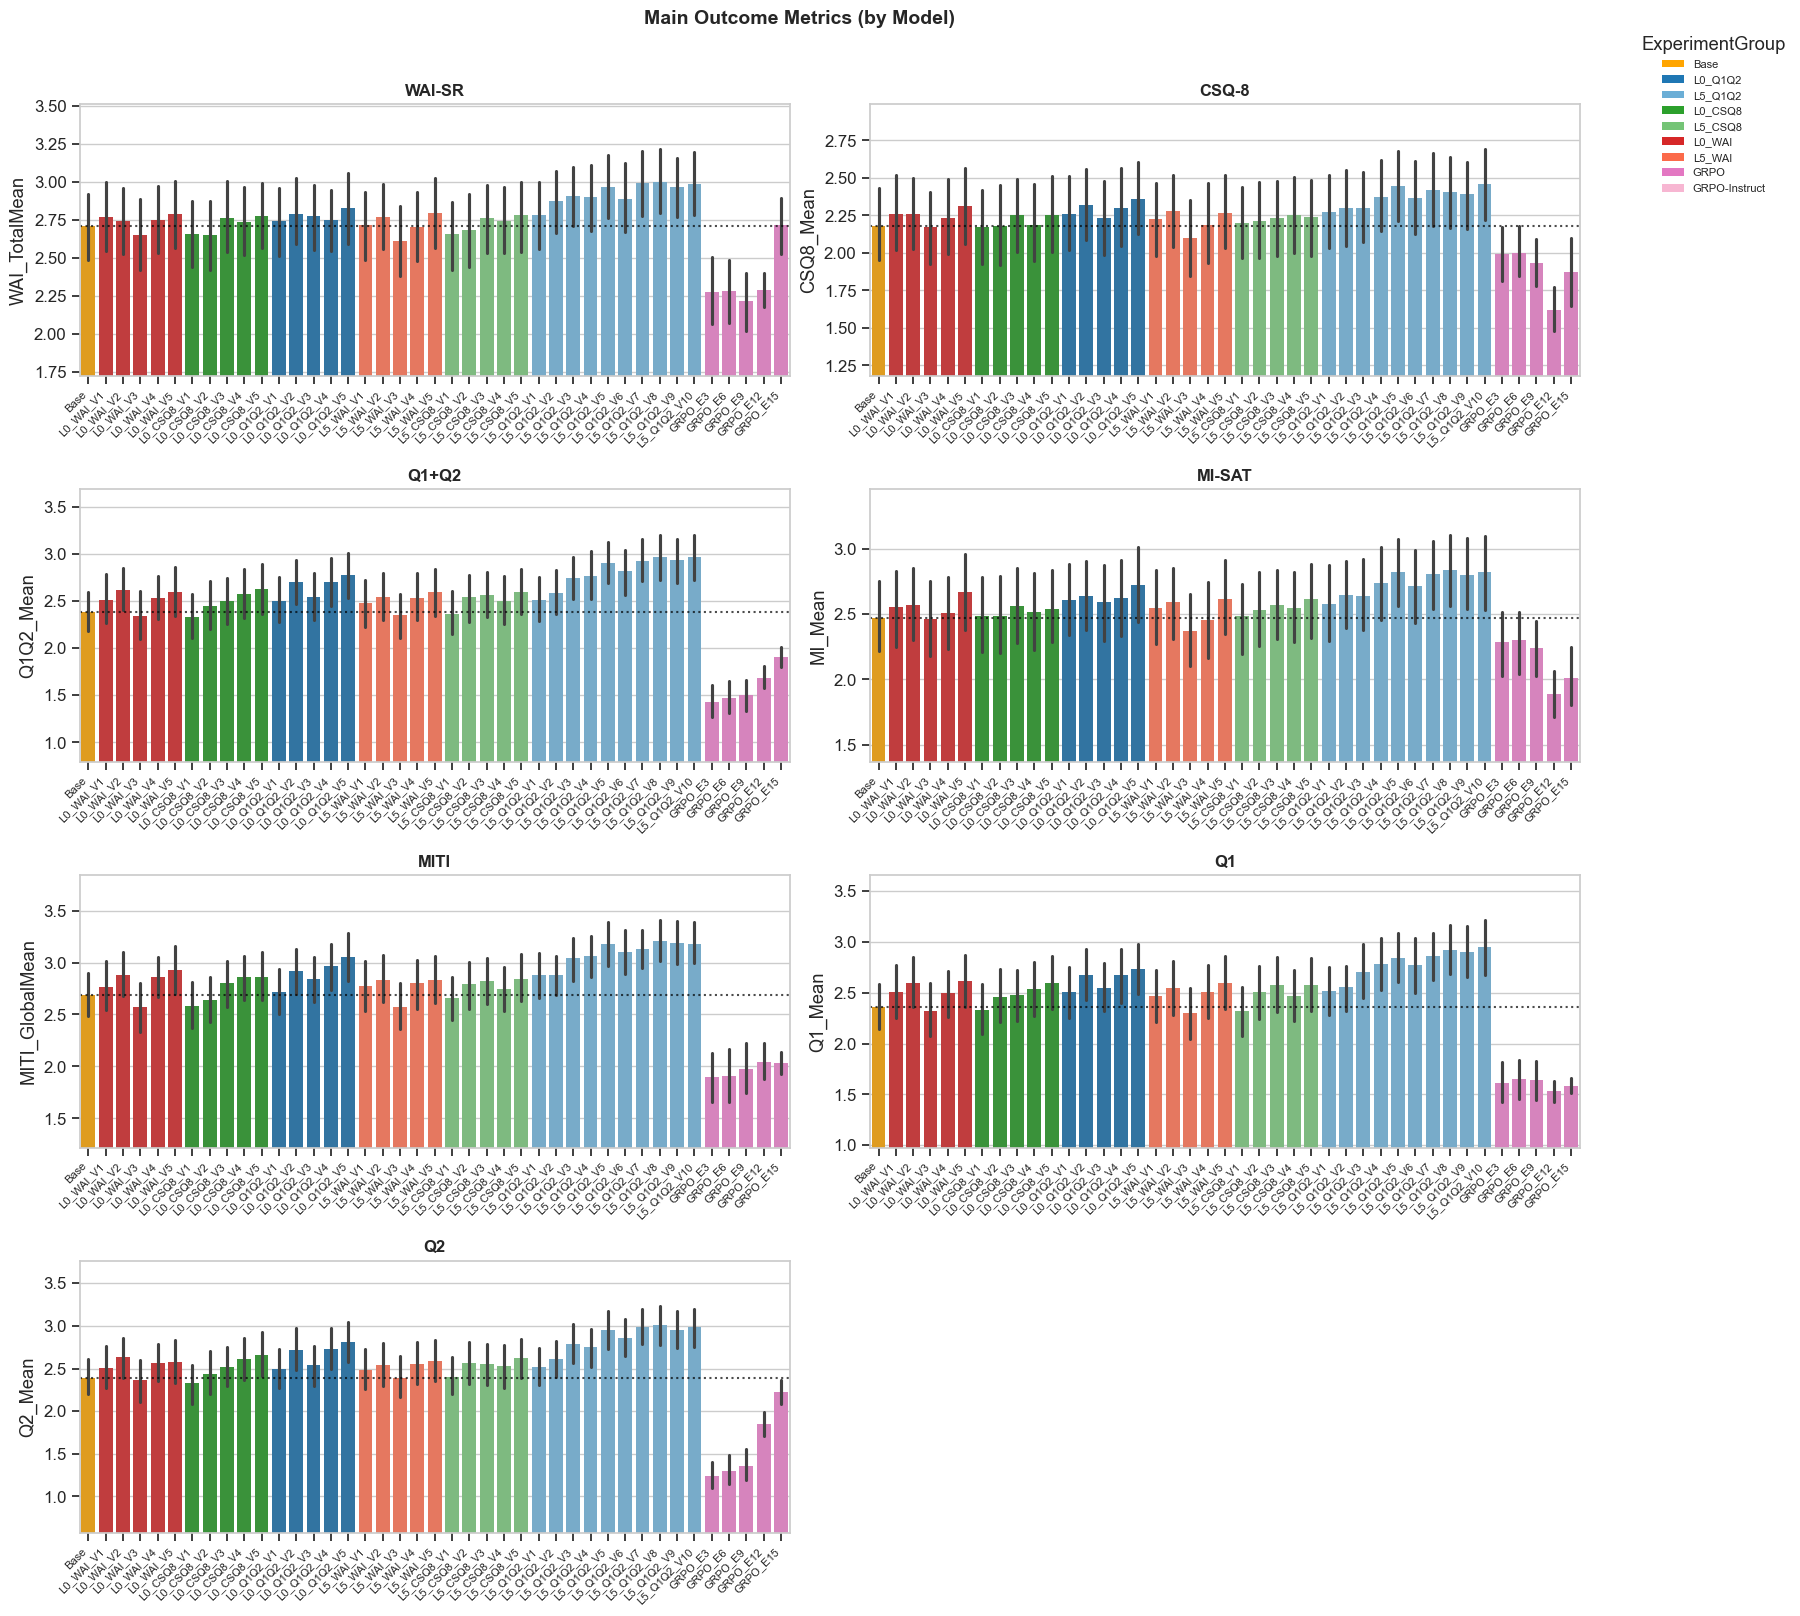

<Figure size 640x480 with 0 Axes>

In [16]:
plot_all_metrics_grid(
    selected_test_cases, group_by="Model", model_order=selected_model_order, ylim="auto", padding=0.25, ctx=ctx, figsize=(16, 16)
 )
plt.suptitle(f"Metric Overview — {selection_label}", fontsize=14, fontweight="bold", y=1.01)
plt.show()

## 4.2 WAI-SR Subscales

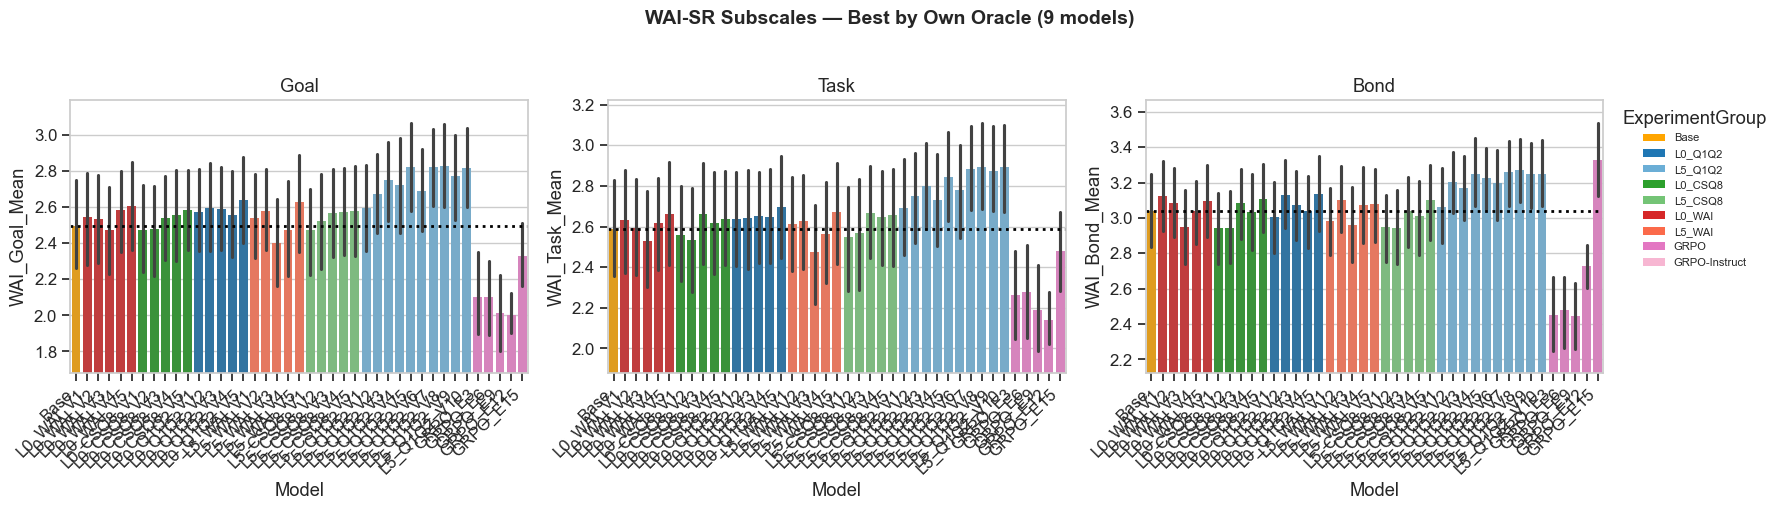

In [17]:
wai_results_df = eval_results.get("WAI-SR")
selected_wai_models = set()
for metric_name, metric_df, _ in selected_test_cases:
    if metric_name == "WAI-SR" and metric_df is not None:
        selected_wai_models = set(metric_df["Model"].astype(str).unique())

if wai_results_df is not None and selected_wai_models:
    wai_plot_df = wai_results_df[wai_results_df["Model"].isin(selected_wai_models)].copy()
    wai_plot_df = apply_model_order(wai_plot_df, MODEL_ORDER)
    wai_model_order = [model_name for model_name in selected_model_order if model_name in wai_plot_df["Model"].unique()]
    plot_subscales(
        wai_plot_df,
        subscale_cols=["WAI_Goal_Mean", "WAI_Task_Mean", "WAI_Bond_Mean"],
        subscale_titles=["Goal", "Task", "Bond"],
        ylim="auto", suptitle=f"WAI-SR Subscales — {selection_label}", model_order=wai_model_order, ctx=ctx,
    )
else:
    print("WAI-SR data not available.")

## 4.3 MITI Subscales

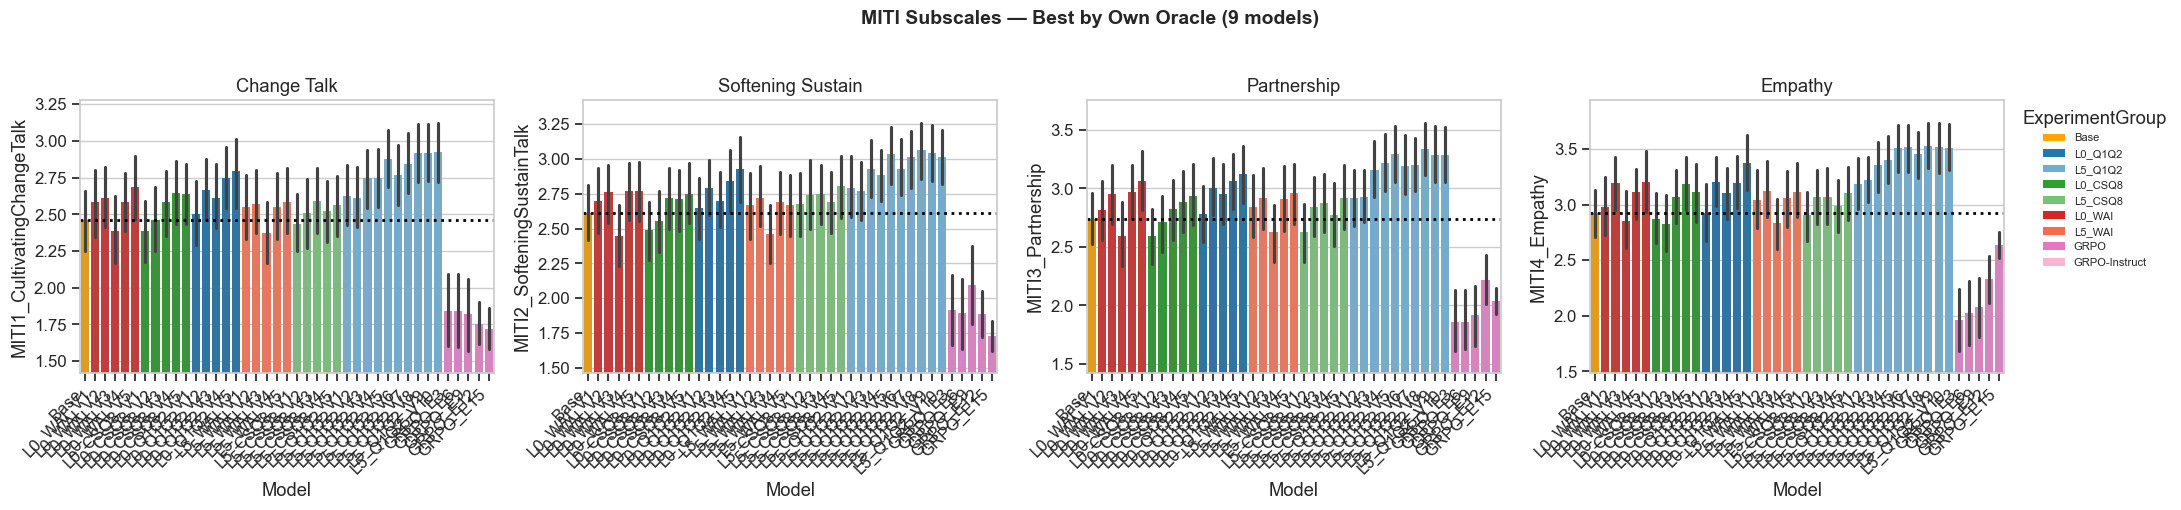

In [18]:
miti_results_df = eval_results.get("MITI")
selected_miti_models = set()
for metric_name, metric_df, _ in selected_test_cases:
    if metric_name == "MITI" and metric_df is not None:
        selected_miti_models = set(metric_df["Model"].astype(str).unique())

if miti_results_df is not None and selected_miti_models:
    miti_plot_df = miti_results_df[miti_results_df["Model"].isin(selected_miti_models)].copy()
    miti_plot_df = apply_model_order(miti_plot_df, MODEL_ORDER)
    miti_model_order = [model_name for model_name in selected_model_order if model_name in miti_plot_df["Model"].unique()]
    plot_subscales(
        miti_plot_df,
        subscale_cols=["MITI1_CultivatingChangeTalk", "MITI2_SofteningSustainTalk", "MITI3_Partnership", "MITI4_Empathy"],
        subscale_titles=["Change Talk", "Softening Sustain", "Partnership", "Empathy"],
        figsize=(22, 5), ylim="auto", suptitle=f"MITI Subscales — {selection_label}", model_order=miti_model_order, ctx=ctx,
    )
else:
    print("MITI data not available.")

## 4.4 Statistical Summary

Three analyses are run per metric. Run them in sequence or independently:

**4.4a Omnibus** — Kruskal-Wallis (non-parametric) and one-way ANOVA (parametric robustness check).
A significant result means *at least one* model differs from the others. Use this as a global screen.

**4.4b vs Baseline** — Mann-Whitney U for each model vs Base, with BH-FDR correction applied per metric.
`q_fdr` is the FDR-adjusted p-value. `Significant` = `q_fdr < 0.05`. `Delta_Mean > 0` means the model beats Base.

**4.4c Pairwise** — All-pairs Mann-Whitney U between models, BH-FDR per metric (k*(k-1)/2 tests).
Only significant pairs (q_fdr < 0.05) are shown.

| Column | Meaning |
|---|---|
| **F (ANOVA)** | Between-group / within-group variance ratio. Larger F → more differentiated models. |
| **η² (effect size)** | Proportion of total variance explained by model (0–1). >0.01 small, >0.06 medium, >0.14 large. |
| **H (Kruskal-Wallis)** | Rank-based analog of F — robust to non-normality. Prefer over ANOVA if Shapiro p < 0.05. |
| **U** | Mann-Whitney U statistic from the pairwise test. |
| **p_raw** | Raw two-sided p-value from Mann-Whitney U. |
| **q_fdr** | BH-FDR adjusted p-value (per metric). Significant if < 0.05. |
| **Delta_Mean** | model_mean − baseline_mean (positive = model improves over Base). |
| **Cohens_d** | Pooled-SD effect size (positive = model A > B or model > Base). |
| **Effect_Size** | negligible / small / medium / large (\|d\| < 0.2 / 0.5 / 0.8). |

In [19]:
stats_results = run_full_stats_battery(selected_test_cases, groupby_levels=["Model"], baseline="Base")

summary_rows = []
for result_key, result_payload in stats_results.items():
    metric_name = result_key.rsplit("_", 1)[0]
    anova_result = result_payload.get("anova") or {}
    kruskal_result = result_payload.get("kruskal") or {}
    anova_p_value = anova_result.get("p_value", 1.0)
    summary_rows.append({
        "Metric": metric_name,
        "F (ANOVA)": round(anova_result.get("F_statistic", float("nan")), 2),
        "p-val (ANOVA)": format_pvalue(anova_p_value),
        "η² (effect size)": round(anova_result.get("eta_squared", float("nan")), 3),
        "H (Kruskal-Wallis)": round(kruskal_result.get("H_statistic", float("nan")), 2),
        "p-val (K-W)": format_pvalue(kruskal_result.get("p_value", 1.0)),
        "Sig?": "✓" if anova_p_value < 0.05 else "",
    })
if summary_rows:
    stats_summary_df = pd.DataFrame(summary_rows).set_index("Metric")
    display(
        stats_summary_df.style
        .background_gradient(subset=["η² (effect size)"], cmap="RdYlGn_r")
        .set_caption(f"4.4a Omnibus — do models differ? ({selection_label})")
    )

c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=

,F (ANOVA),p-val (ANOVA),η² (effect size),H (Kruskal-Wallis),p-val (K-W),Sig?
Metric,,,,,,
WAI-SR,2.730000,3.22e-08 ***,0.027000,108.890000,2.71e-08 ***,✓
CSQ-8,1.660000,0.0057 **,0.017000,66.280000,0.0056 **,✓
Q1+Q2,10.110000,2.69e-58 ***,0.094000,505.360000,7.23e-82 ***,✓
MI-SAT,1.970000,2.77e-04 ***,0.020000,87.250000,2.29e-05 ***,✓
MITI,9.380000,4.70e-53 ***,0.088000,338.430000,6.56e-49 ***,✓
Q1,8.490000,9.85e-47 ***,0.080000,409.930000,7.31e-63 ***,✓
Q2,12.180000,4.97e-73 ***,0.111000,642.310000,1.24e-109 ***,✓


In [20]:
# ── 4.4b: Each model vs Base — Mann-Whitney U + BH-FDR (per metric) ──
vs_base_df = compare_all_vs_baseline(selected_test_cases, baseline="Base")

if vs_base_df.empty:
    print("No data for vs-baseline comparison.")
else:
    n_tests = len(vs_base_df)
    n_sig = vs_base_df["Significant"].sum()
    print(f"Tests: {n_tests} | Significant after BH-FDR: {n_sig}")

    for metric_name in vs_base_df["Metric"].unique():
        sl = vs_base_df[vs_base_df["Metric"] == metric_name].copy()
        # drop rows that are not significant after BH-FDR correction
        sl = sl[sl["Significant"]].copy()
        n_metric_sig = int(sl["Significant"].sum())
        display(
            sl.drop(columns=["Metric"]).reset_index(drop=True)
            .style
            .format({
                "Mean":          "{:.3f}",
                "Baseline_Mean": "{:.3f}",
                "Delta_Mean":    "{:.3f}",
                "U":             "{:.0f}",
                "p_raw":         "{:.4f}",
                "q_fdr":         "{:.4f}",
                "Cohens_d":      "{:.3f}",
            })
            .apply(
                lambda row:  ["background-color: #d4edda" if row["Significant"] else "" for _ in row],
                axis=1,
            )
            .set_caption(
                f"4.4b {metric_name} — vs Base ({n_metric_sig}/{len(sl)} significant, BH-FDR, {selection_label})"
            )
        )

Tests: 280 | Significant after BH-FDR: 45


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size
0,GRPO_E3,96,1.893,2.685,-0.792,2662,0.0000,0.0000,True,-0.695,medium
1,GRPO_E6,96,1.904,2.685,-0.781,2682,0.0000,0.0000,True,-0.676,medium
2,GRPO_E9,96,1.979,2.685,-0.706,2834,0.0000,0.0000,True,-0.624,medium
3,GRPO_E15,96,2.031,2.685,-0.654,2872,0.0000,0.0001,True,-0.812,large
4,L5_Q1Q2_V8,96,3.211,2.685,0.526,5966,0.0004,0.0031,True,0.521,medium
5,L5_Q1Q2_V5,96,3.177,2.685,0.492,5934,0.0005,0.0036,True,0.485,small
6,GRPO_E12,96,2.047,2.685,-0.638,3318,0.0007,0.0039,True,-0.677,medium
7,L5_Q1Q2_V10,96,3.182,2.685,0.497,5848,0.0012,0.0060,True,0.499,small
8,L5_Q1Q2_V9,96,3.190,2.685,0.505,5826,0.0015,0.0065,True,0.493,small
9,L5_Q1Q2_V6,96,3.102,2.685,0.417,5715,0.0039,0.0140,True,0.405,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size
0,GRPO_E3,96,1.610,2.360,-0.750,2317,0.0000,0.0000,True,-0.699,medium
1,GRPO_E6,96,1.648,2.360,-0.713,2424,0.0000,0.0000,True,-0.659,medium
2,GRPO_E9,96,1.637,2.360,-0.723,2430,0.0000,0.0000,True,-0.684,medium
3,GRPO_E12,96,1.529,2.360,-0.831,2600,0.0000,0.0000,True,-0.932,large
4,GRPO_E15,96,1.585,2.360,-0.775,2904,0.0000,0.0000,True,-0.917,large
5,L5_Q1Q2_V10,96,2.950,2.360,0.590,5821,0.0015,0.0084,True,0.477,small
6,L5_Q1Q2_V8,96,2.919,2.360,0.558,5824,0.0015,0.0084,True,0.465,small
7,L5_Q1Q2_V9,96,2.906,2.360,0.546,5801,0.0018,0.0091,True,0.450,small
8,L5_Q1Q2_V7,96,2.865,2.360,0.504,5762,0.0025,0.0111,True,0.427,small
9,L5_Q1Q2_V5,96,2.844,2.360,0.483,5745,0.0028,0.0113,True,0.410,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size
0,GRPO_E3,96,1.427,2.377,-0.950,1548,0.0000,0.0000,True,-0.993,large
1,GRPO_E6,96,1.475,2.377,-0.903,1698,0.0000,0.0000,True,-0.929,large
2,GRPO_E9,96,1.499,2.377,-0.878,1824,0.0000,0.0000,True,-0.910,large
3,GRPO_E12,96,1.687,2.377,-0.690,2842,0.0000,0.0000,True,-0.797,medium
4,L5_Q1Q2_V10,96,2.968,2.377,0.590,5968,0.0004,0.0024,True,0.513,medium
5,L5_Q1Q2_V7,96,2.928,2.377,0.551,5968,0.0004,0.0024,True,0.501,medium
6,L5_Q1Q2_V8,96,2.963,2.377,0.586,5990,0.0003,0.0024,True,0.519,medium
7,L5_Q1Q2_V5,96,2.900,2.377,0.523,5939,0.0005,0.0027,True,0.476,small
8,L5_Q1Q2_V9,96,2.931,2.377,0.554,5878,0.0010,0.0043,True,0.485,small
9,L5_Q1Q2_V6,96,2.814,2.377,0.436,5664,0.0061,0.0243,True,0.381,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size
0,GRPO_E3,96,1.244,2.395,-1.151,808,0.0000,0.0000,True,-1.265,large
1,GRPO_E6,96,1.302,2.395,-1.093,980,0.0000,0.0000,True,-1.161,large
2,GRPO_E9,96,1.361,2.395,-1.034,1216,0.0000,0.0000,True,-1.090,large
3,GRPO_E12,96,1.846,2.395,-0.549,3104,0.0001,0.0008,True,-0.613,medium
4,L5_Q1Q2_V7,96,2.992,2.395,0.597,6106,0.0001,0.0008,True,0.570,medium
5,L5_Q1Q2_V8,96,3.007,2.395,0.613,6072,0.0001,0.0009,True,0.563,medium
6,L5_Q1Q2_V10,96,2.985,2.395,0.591,6040,0.0002,0.0011,True,0.540,medium
7,L5_Q1Q2_V5,96,2.957,2.395,0.562,6023,0.0002,0.0012,True,0.537,medium
8,L5_Q1Q2_V9,96,2.957,2.395,0.562,5935,0.0006,0.0025,True,0.512,medium
9,L5_Q1Q2_V6,96,2.858,2.395,0.464,5725,0.0037,0.0148,True,0.419,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Significant,Cohens_d,Effect_Size


In [ ]:
# ── 4.4c: All pairwise — Mann-Whitney U + BH-FDR (per metric) ──
# With k models this computes k*(k-1)/2 tests per metric; only significant pairs shown.
pairwise_df = compare_all_pairwise(selected_test_cases)

if pairwise_df.empty:
    print("No significant pairwise model differences after BH-FDR correction.")
else:
    print(f"Significant pairs after BH-FDR: {len(pairwise_df)} total")
    for metric_name in pairwise_df["Metric"].unique():
        sl = pairwise_df[pairwise_df["Metric"] == metric_name].copy()
        display(
            sl.drop(columns=["Metric"]).reset_index(drop=True)
            .style
            .format({
                "Mean_A":   "{:.3f}",
                "Mean_B":   "{:.3f}",
                "Delta":    "{:.3f}",
                "U":        "{:.0f}",
                "p_raw":    "{:.4f}",
                "q_fdr":    "{:.4f}",
                "Cohens_d": "{:.3f}",
            })
            .set_caption(
                f"4.4c {metric_name} — Significant pairs ({len(sl)}, BH-FDR, {selection_label})"
            )
        )

## 4.5 Model Rankings

**Mean** = average score across 96 conversations. **Rank** = 1 is best (highest mean). **Avg Rank** = mean rank across all metrics — lower is better overall. **Std** = consistency (lower = more reliable). Green = better performance.

In [22]:
combined_rankings = None
for metric_name, metric_df, metric_column in iter_metric_cases(selected_test_cases):
    ranking_df = metric_df.groupby("Model", observed=True)[metric_column].agg(["mean", "std"]).reset_index()
    ranking_df["rank"] = ranking_df["mean"].rank(ascending=False, method="min").astype(int)
    ranking_df = ranking_df.rename(columns={"mean": f"{metric_name} Mean", "std": f"{metric_name} Std", "rank": f"{metric_name} Rank"})
    ranking_df[f"{metric_name} Mean"] = ranking_df[f"{metric_name} Mean"].round(3)
    ranking_df[f"{metric_name} Std"] = ranking_df[f"{metric_name} Std"].round(3)
    combined_rankings = ranking_df if combined_rankings is None else combined_rankings.merge(ranking_df, on="Model", how="outer")

if combined_rankings is not None:
    rank_cols = [col_name for col_name in combined_rankings.columns if col_name.endswith(" Rank")]
    combined_rankings["Avg Rank"] = combined_rankings[rank_cols].mean(axis=1).round(1)
    mean_cols = [col_name for col_name in combined_rankings.columns if col_name.endswith(" Mean")]
    std_cols  = [col_name for col_name in combined_rankings.columns if col_name.endswith(" Std")]
    combined_rankings = combined_rankings[["Model", "Avg Rank"] + mean_cols + rank_cols + std_cols]
    combined_rankings = combined_rankings.sort_values("Avg Rank").reset_index(drop=True)
    # put row with Model="Base" first
    base_mask = combined_rankings["Model"].astype(str).str.lower().eq("base")
    combined_rankings = pd.concat([combined_rankings[base_mask], combined_rankings[~base_mask]])
    print(combined_rankings)
    styler = combined_rankings.style
    # Color the colums (remove\palce comments to disable)
    styler = styler.background_gradient(subset=["Avg Rank"], cmap="RdYlGn_r", vmin=1, vmax=len(combined_rankings))
    # for col_name in mean_cols: styler = styler.background_gradient(subset=[col_name], cmap="RdYlGn")
    # for col_name in rank_cols: styler = styler.background_gradient(subset=[col_name], cmap="RdYlGn_r")
    # for col_name in std_cols:  styler = styler.background_gradient(subset=[col_name], cmap="RdYlGn_r")
    # show up to 2 digits after decimal
    styler = styler.format({col: "{:.2f}" for col in mean_cols + std_cols + ["Avg Rank"]})
    #display(styler.set_caption(f"Model rankings across all metrics ({selection_label})"))

          Model  Avg Rank  WAI-SR Mean  CSQ-8 Mean  Q1+Q2 Mean  MI-SAT Mean  \
31         Base      31.9        2.707       2.182       2.378        2.470   
0    L5_Q1Q2_V8       1.7        2.997       2.406       2.963        2.833   
1   L5_Q1Q2_V10       2.1        2.985       2.462       2.968        2.821   
2    L5_Q1Q2_V7       3.4        2.989       2.418       2.928        2.806   
3    L5_Q1Q2_V9       3.7        2.965       2.391       2.931        2.799   
4    L5_Q1Q2_V5       3.9        2.964       2.447       2.900        2.823   
5    L5_Q1Q2_V6       6.9        2.889       2.368       2.814        2.717   
6    L5_Q1Q2_V4       7.0        2.901       2.374       2.767        2.736   
7    L0_Q1Q2_V5       7.9        2.824       2.361       2.770        2.719   
8    L5_Q1Q2_V3       9.1        2.905       2.298       2.745        2.637   
9    L0_Q1Q2_V2      10.9        2.790       2.316       2.697        2.641   
10    L0_WAI_V5      12.6        2.788       2.311  

## 4.6 Lookahead Comparison (L0 vs L5)

Lookahead controls how many future turns the RL oracle sees during training. L0 = current turn only; L5 = 5 turns ahead. Do these settings produce measurably different models?

In [23]:
lookahead_comparison_results = compare_lookahead(selected_test_cases)
summary_rows = []
for metric_name, metric_breakdown in lookahead_comparison_results.items():
    overall_result = metric_breakdown.get("overall", {})
    summary_rows.append({
        "Metric": metric_name,
        "L0 mean": round(overall_result.get("group1_mean", float("nan")), 3),
        "L5 mean": round(overall_result.get("group2_mean", float("nan")), 3),
        "U": round(overall_result.get("U_statistic", float("nan")), 1),
        "p": format_pvalue(overall_result.get("p_value", 1.0)),
        "d": round(overall_result.get("cohens_d", float("nan")), 3),
        "effect": overall_result.get("effect_size", ""),
        "sig": "*" if overall_result.get("significant") else "",
    })
if summary_rows:
    display(pd.DataFrame(summary_rows).set_index("Metric").style.set_caption(f"L0 vs L5 — Mann-Whitney U ({selection_label})"))
else:
    print("No L0/L5 data available for comparison.")

,L0 mean,L5 mean,U,p,d,effect,sig
Metric,,,,,,,
WAI-SR,2.743000,2.823000,1322201.500000,0.0300 *,-0.072000,negligible,*
CSQ-8,2.250000,2.296000,1333484.000000,0.0717,-0.037000,negligible,
Q1+Q2,2.552000,2.658000,1295199.500000,0.0017 **,-0.087000,negligible,*
MI-SAT,2.569000,2.636000,1330785.000000,0.0613,-0.048000,negligible,
MITI,2.816000,2.927000,1294987.000000,0.0016 **,-0.100000,negligible,*
Q1,2.539000,2.634000,1314415.500000,0.0136 *,-0.074000,negligible,*
Q2,2.565000,2.683000,1288469.500000,7.30e-04 ***,-0.099000,negligible,*


## 4.7 Cross-Metric Correlations

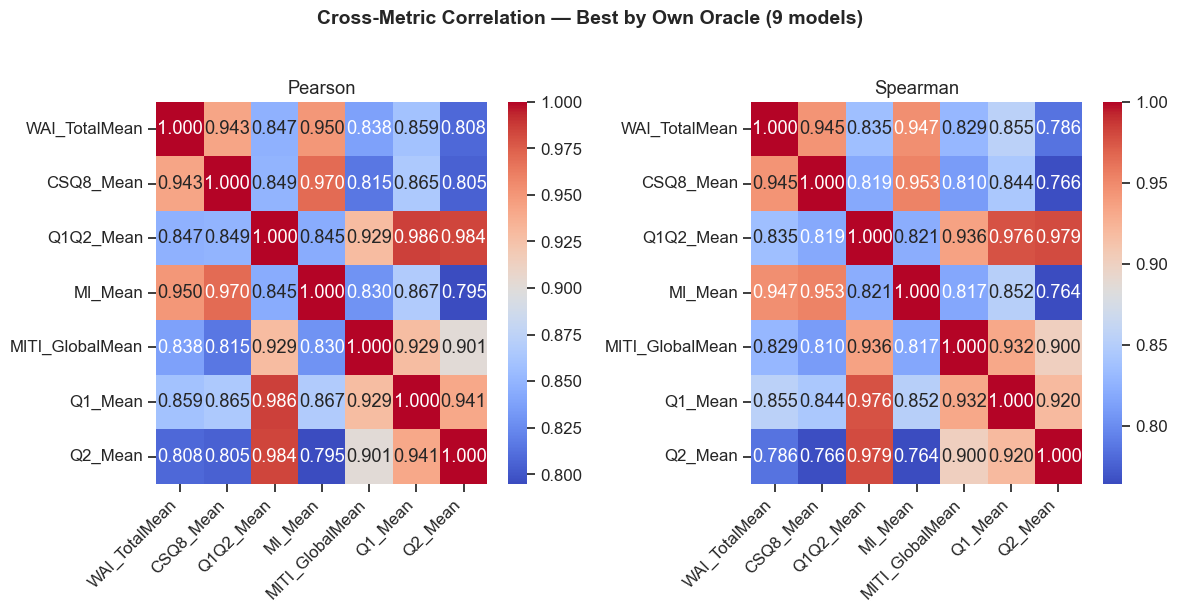

In [24]:
merged_metrics_df = build_merged_metrics(selected_test_cases)
if merged_metrics_df is not None:
    plot_correlation_heatmaps(merged_metrics_df, title=f"Cross-Metric Correlation — {selection_label}")
else:
    print("Need at least 2 metrics for correlation analysis.")

## 4.8 Patient Characteristics

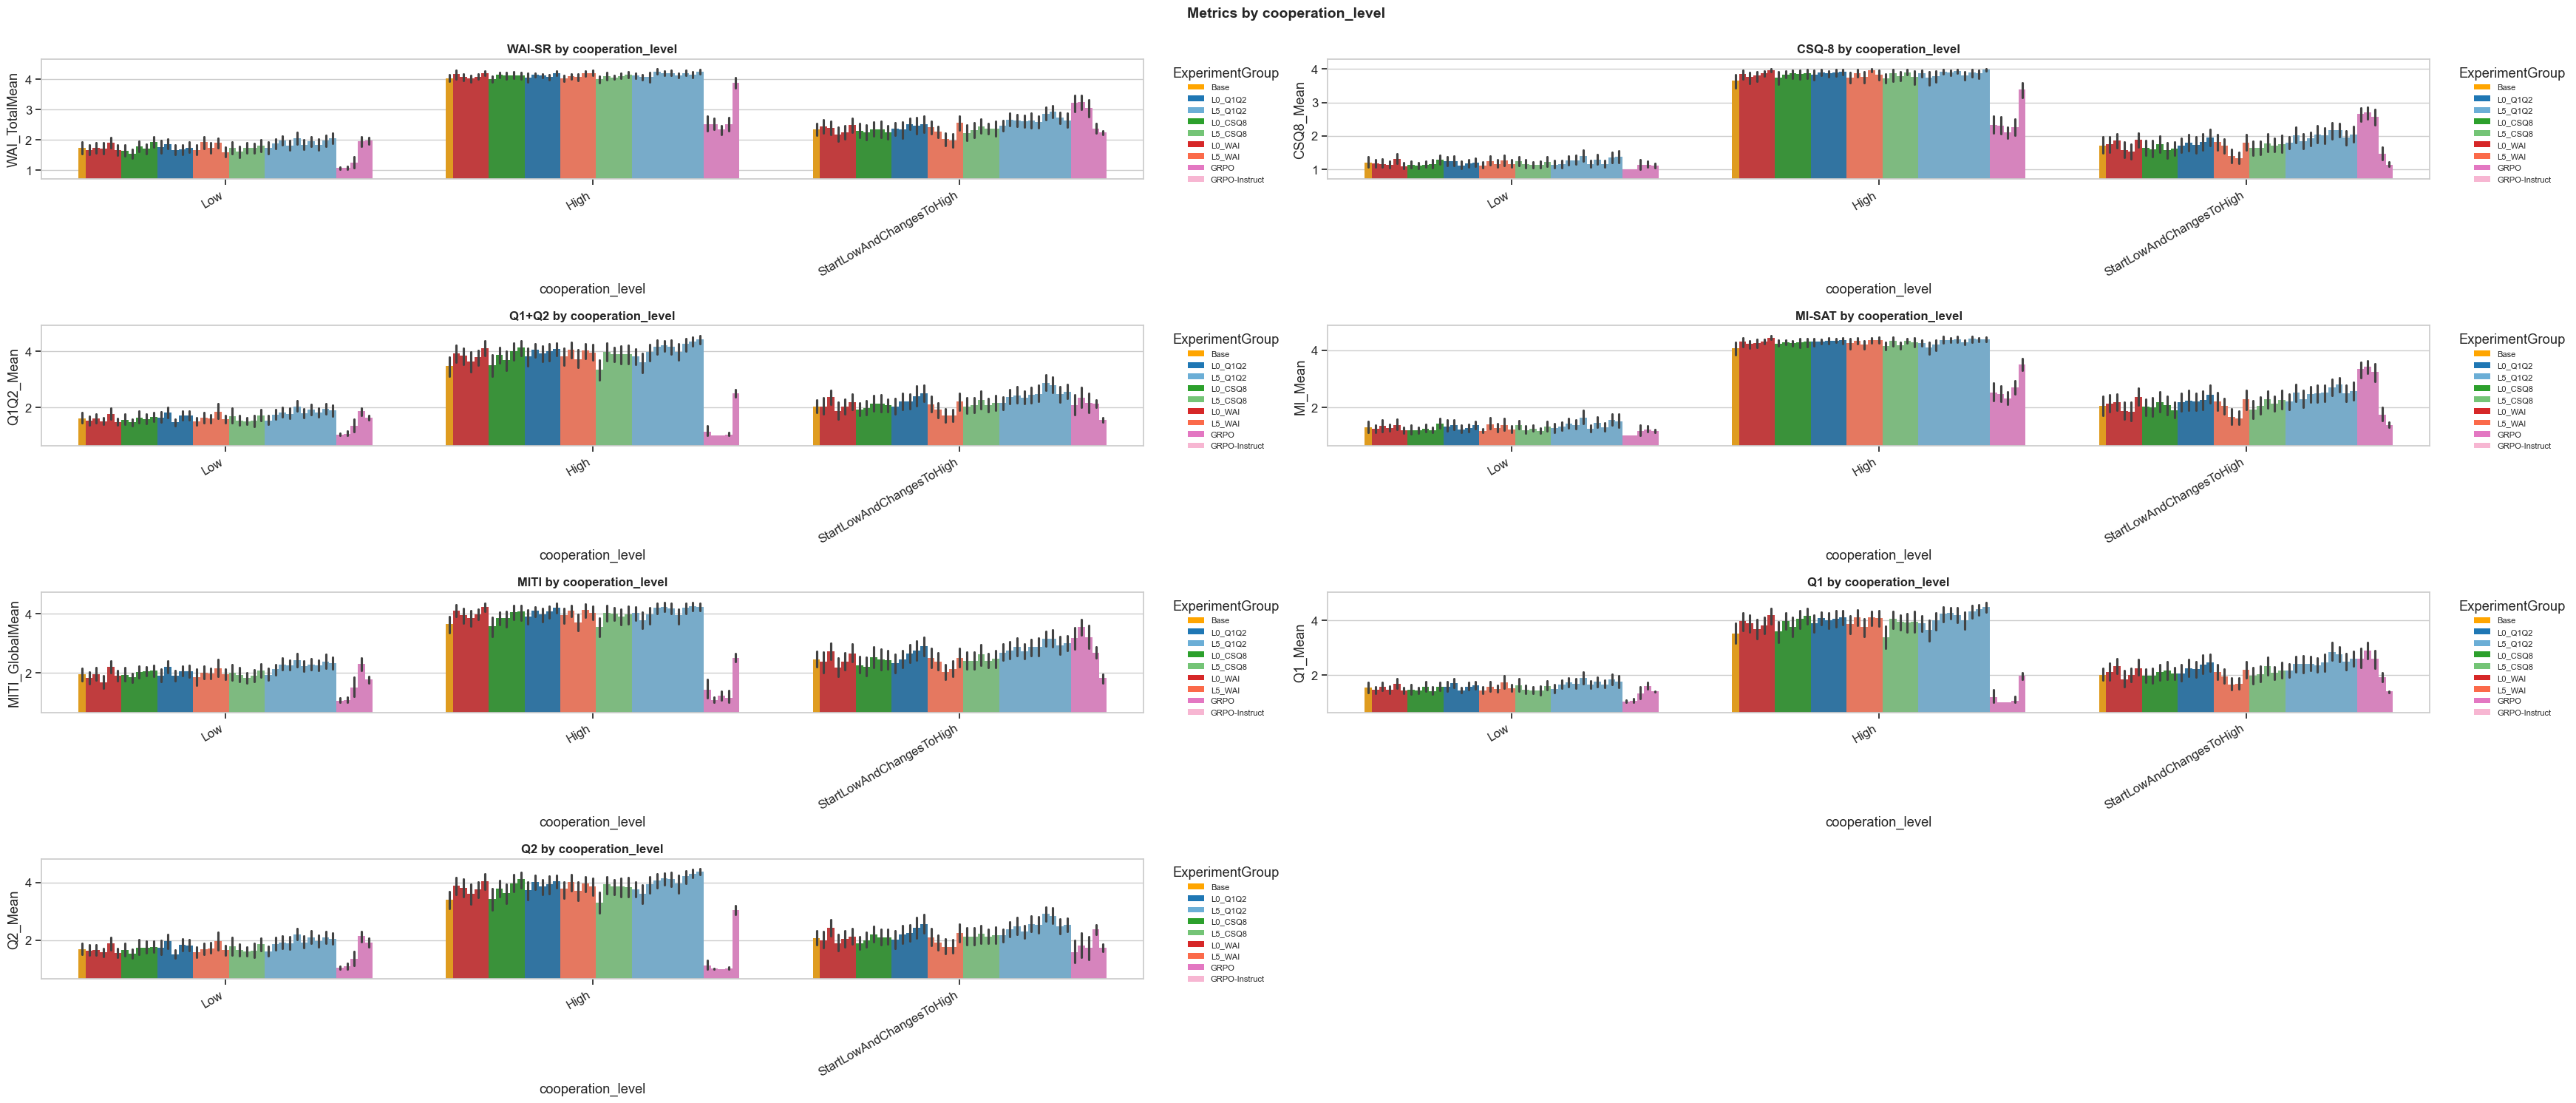

(<Figure size 3500x1500 with 8 Axes>,
 array([[<Axes: title={'center': 'WAI-SR by cooperation_level'}, xlabel='cooperation_level', ylabel='WAI_TotalMean'>,
         <Axes: title={'center': 'CSQ-8 by cooperation_level'}, xlabel='cooperation_level', ylabel='CSQ8_Mean'>],
        [<Axes: title={'center': 'Q1+Q2 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q1Q2_Mean'>,
         <Axes: title={'center': 'MI-SAT by cooperation_level'}, xlabel='cooperation_level', ylabel='MI_Mean'>],
        [<Axes: title={'center': 'MITI by cooperation_level'}, xlabel='cooperation_level', ylabel='MITI_GlobalMean'>,
         <Axes: title={'center': 'Q1 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q1_Mean'>],
        [<Axes: title={'center': 'Q2 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q2_Mean'>,
         <Axes: >]], dtype=object))

In [25]:
metric_dataframes = {metric_name: metric_df for metric_name, metric_df, _ in iter_metric_cases(selected_test_cases)}
metric_columns = {metric_name: metric_column for metric_name, _, metric_column in iter_metric_cases(selected_test_cases)}
plot_metrics_by_patient_characteristic(
    metric_dataframes, metric_columns, "cooperation_level",
    palette=ctx.experiment_palette, model_palette=ctx.model_palette,
    figsize=(35, 15), ylim="auto", ctx=ctx,
)

## 4.9 Conversation Length

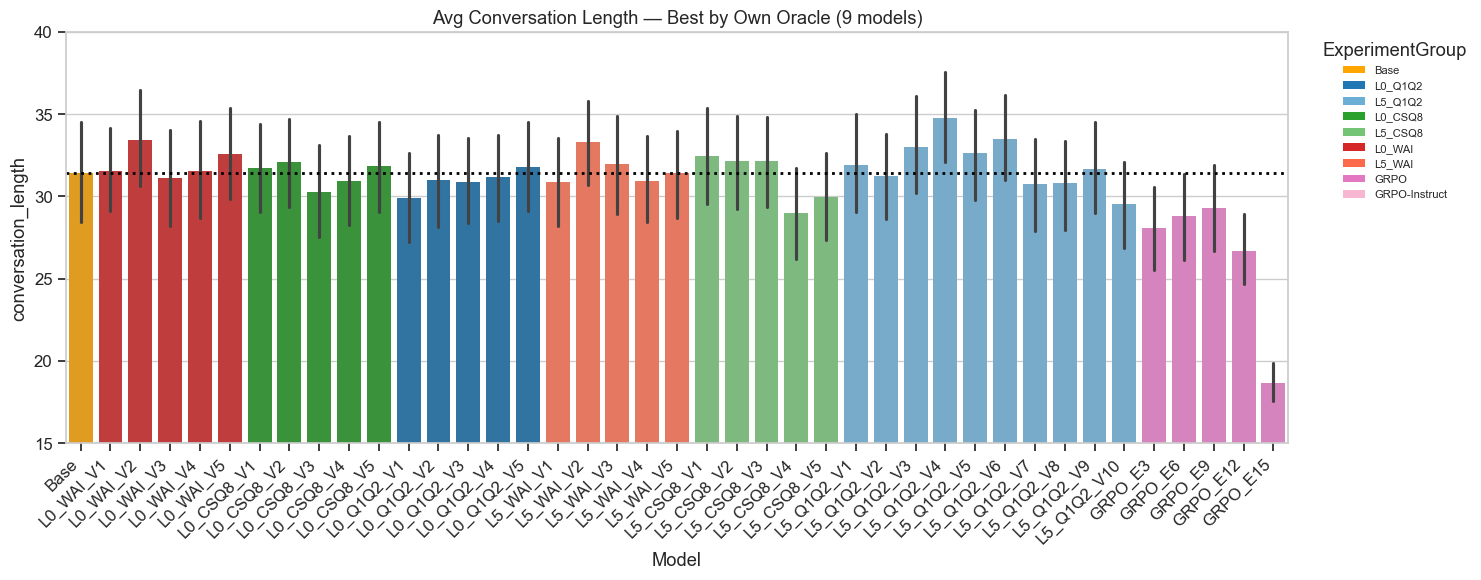

(<Figure size 1500x600 with 1 Axes>,
 <Axes: title={'center': 'Avg Conversation Length — Best by Own Oracle (9 models)'}, xlabel='Model', ylabel='conversation_length'>)

In [26]:
models_present_in_selection = set(selected_combined_data["Model"].astype(str).unique())
plot_model_order = [model_name for model_name in selected_model_order if model_name in models_present_in_selection]
plot_metric_by_model(
    selected_combined_data, metric="conversation_length",
    title=f"Avg Conversation Length — {selection_label}",
    ylim=(15, 40), model_order=plot_model_order, ctx=ctx,
)

## 4.10 Session Ending Patterns

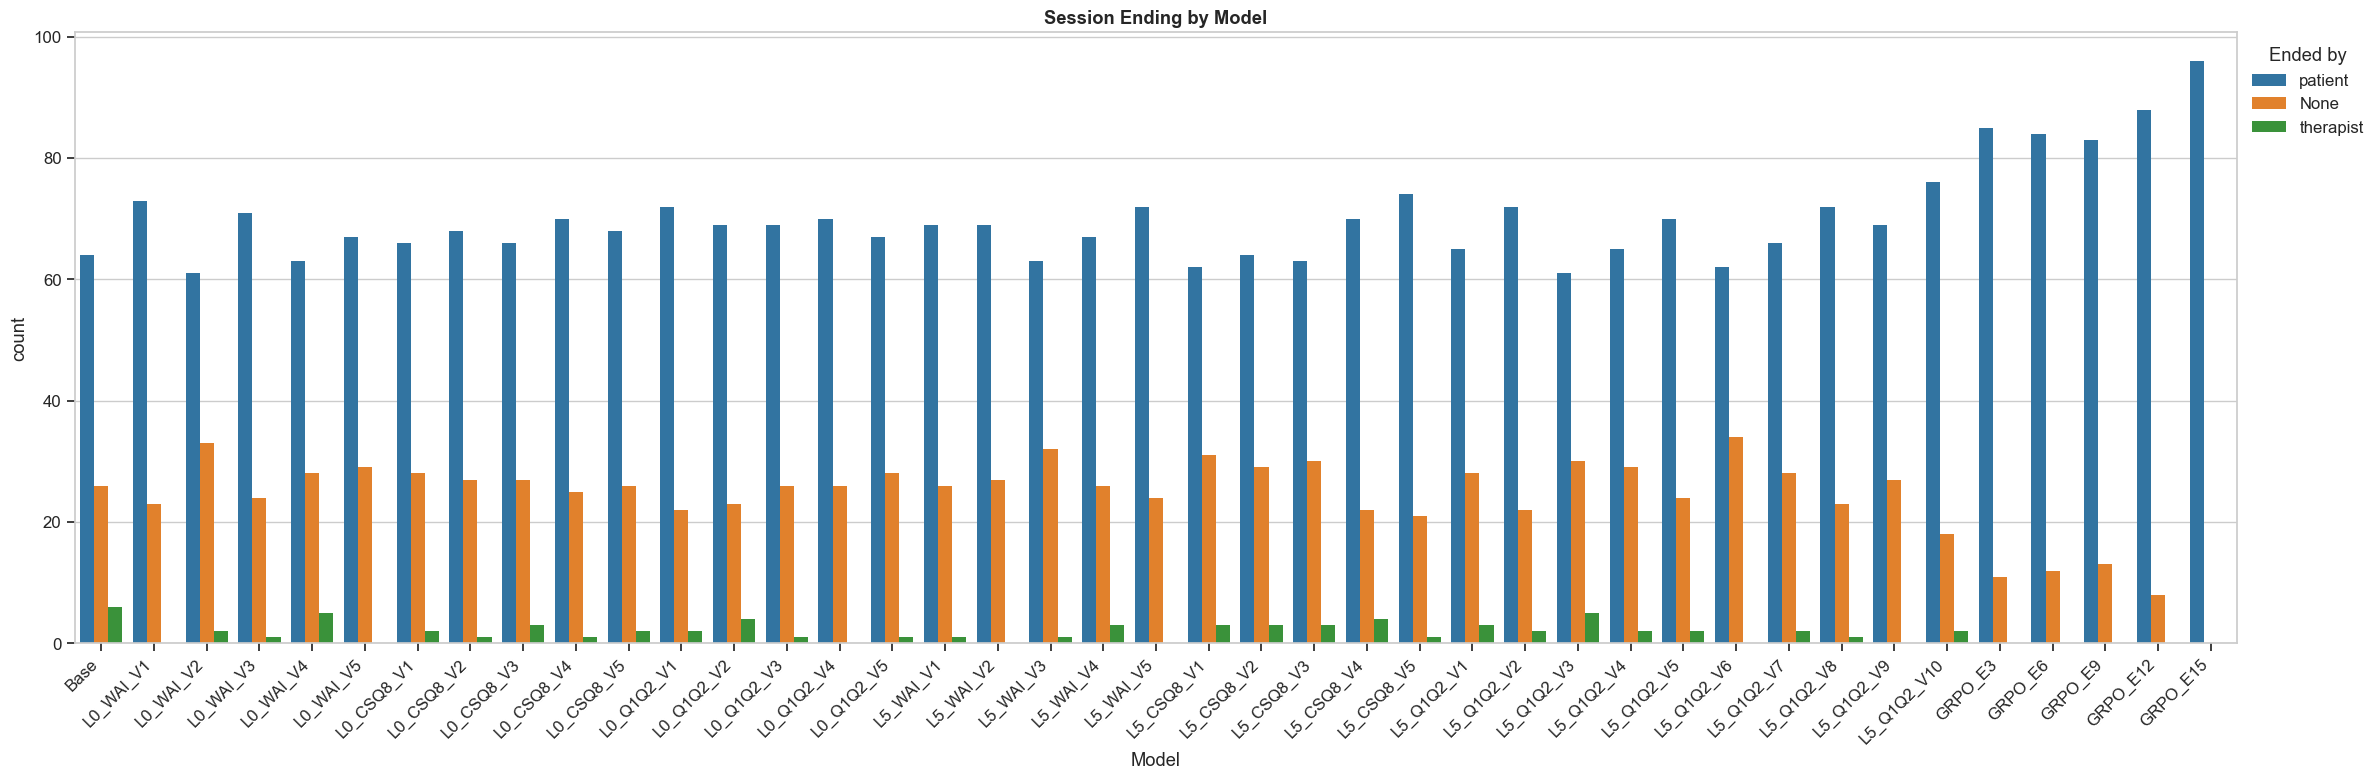

(<Figure size 2400x800 with 1 Axes>,
 <Axes: title={'center': 'Session Ending by Model'}, xlabel='Model', ylabel='count'>)

In [27]:
models_present_in_selection = set(selected_combined_data["Model"].astype(str).unique())
plot_model_order = [model_name for model_name in selected_model_order if model_name in models_present_in_selection]
plot_session_ending(selected_combined_data, palette=ctx.experiment_palette, figsize=(24, 8), model_order=plot_model_order)